# Hier-COS Output Analysis

This notebook analyzes seeded training/test artifacts in `/scratch/g.saggini1/outputs/` and compares Hier-COS variants across datasets. Each experiment is a parent directory containing `seed_<seed>` runs; curves and final metrics report the mean and sample standard deviation across those seeds.

Default setup:
- baselines: `hiercos_<dataset>_global_softmax_ce_reg_baseline_<weight>` with `equal` and `kl_leaf`
- orthogonalize-all lex runs: `hiercos_<dataset>_global_softmax_ce_reg_lex_orthogonalize_all_<mode>`
- conflict-only lex runs: `hiercos_<dataset>_global_softmax_ce_reg_lex_conflict_only_<mode>`
- coarse-first transform ablations: `hiercos_<dataset>_global_softmax_ce_reg_lex_orthogonalize_all_coarse_first_transform_<transform>`
- targeted normalization ablation: run with `model.loss=level_softmax_ce_reg` using explicit output directories

It includes:
- validation curves for `FPA`, `weighted AP`, `TICE`, and `AHD`,
- per-level validation top-down/independent accuracy curves,
- training loss comparisons (`total`, `ce`, `reg`, `kl`, and exact weighted `loss_level_*` when available),
- optional projection/gradient diagnostics when those metrics are present in logs,
- final test comparison tables with deltas versus dataset baseline.


In [11]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import (
    HCastAnalysis as HierCosAnalysis,
    HCastAnalysisConfig as HierCosAnalysisConfig,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [12]:
INCLUDE_BASELINES = True
BASELINE_COLOR = "#243ab4"

BASELINE_BY_DATASET = {
    'cifar-100': {'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    'cub-200-2011': {'run_dir': 'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    'fgvc-aircraft': {'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    'inat19': {'run_dir': 'hiercos_inat19_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
}

MANUAL_RUNS = [
    # Equal-weight non-lex baselines
    # {'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},
    # {'run_dir': 'hiercos_cub200_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},
    # {'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},
    # {'run_dir': 'hiercos_inat19_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},

    
    # level-softmax-ce-reg
    {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS level softmax kl_leaf baseline'},
    {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS level softmax kl_leaf baseline'},
    {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS level softmax kl_leaf baseline'},
    {'run_dir': 'hiercos_inat19_level_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS level softmax kl_leaf baseline'},
    
    {'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf_identity baseline'},
    {'run_dir': 'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf_identity baseline'},
    {'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf_identity baseline'},
    {'run_dir': 'hiercos_inat19_global_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    # level-softmax-ce-reg identity
    {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS level softmax kl_leaf_identity baseline'},
    {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS level softmax kl_leaf_identity baseline'},
    {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS level softmax kl_leaf_identity baseline'},
    {'run_dir': 'hiercos_inat19_level_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS level softmax kl_leaf baseline'},

    # global-softmax Orthogonalize-all lex runs 
    # *[
    #     {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_orthogonalize_all_{mode}',
    #      'label': f'Hier-COS global softmax {mode} orthogonalize_all'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
    #     for mode in ('coarse_first', '')
    # ],
    *[
        {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_orthogonalize_all_{mode}_identity',
         'label': f'Hier-COS global softmax {mode} orthogonalize_all identity'}
        for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
        for mode in ('coarse_first', '')
    ],
    # *[
    #     {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_orthogonalize_all_{mode}_kl_leaf',
    #      'label': f'Hier-COS global softmax {mode} orthogonalize_all kl_leaf'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
    #     for mode in ('coarse_first', '')
    # ],
    # level-softmax Orthogonalize-all lex runs
    # *[
    #     {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_orthogonalize_all_{mode}',
    #      'label': f'Hier-COS level softmax {mode} orthogonalize_all'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
    #     for mode in ('coarse_first', '')
    # ],
    *[
        {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_orthogonalize_all_{mode}_identity',
         'label': f'Hier-COS level softmax {mode} orthogonalize_all identity'}
        for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
        for mode in ('coarse_first', '')
    ],
    # *[
    #     {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_orthogonalize_all_{mode}_kl_leaf',
    #      'label': f'Hier-COS level softmax {mode} orthogonalize_all kl_leaf'}
    #     for dataset in ('cub200', 'aircraft')
    #     for mode in ('coarse_first', '')
    # ],

    # # Conflict-only lex runs
    # *[
    #     {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_conflict_only_{mode}',
    #      'label': f'Hier-COS global softmax {mode} conflict_only'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
    #     for mode in ('coarse_first', 'fine_first')
    # ],

    # Uncomment after running transform ablations.
    # *[
    #     {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_orthogonalize_all_coarse_first_{transform}',
    #      'label': f'Hier-COS global softmax coarse_first {transform}'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
    #     for transform in ('bn_linear', 'final_only')
    # ],
    # *[
    #     {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_orthogonalize_all_coarse_first_{transform}_kl_leaf_identity',
    #      'label': f'Hier-COS level softmax coarse_first {transform} identity'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
    #     for transform in ('', 'final_only')
    # ],
]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]


In [13]:
config = HierCosAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = HierCosAnalysis.from_config(config)
analysis.print_run_summary()


Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_inat19_level_softmax_ce_reg_baseline_kl_leaf
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_inat19_global_softmax_ce_reg_baseline_kl_leaf_identity
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_inat19_level_softmax_ce_reg_baseline_kl_leaf_identity
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_lex_orthogonalize_all__identity
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cub200_global_softmax_ce_reg_lex_orthogonalize_all__identity
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_aircraft_global_softmax_ce_reg_lex_orthogonalize_all__identity
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_inat19_global_softmax_ce_reg_lex_orthogonalize_all_coarse_first_identity
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_in

## Hier-COS Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- color = run
- line style = mode (`topdown` solid, `independent` dashed)

Metrics shown: `FPA`, `wAP`, `TICE`, and `AHD`.


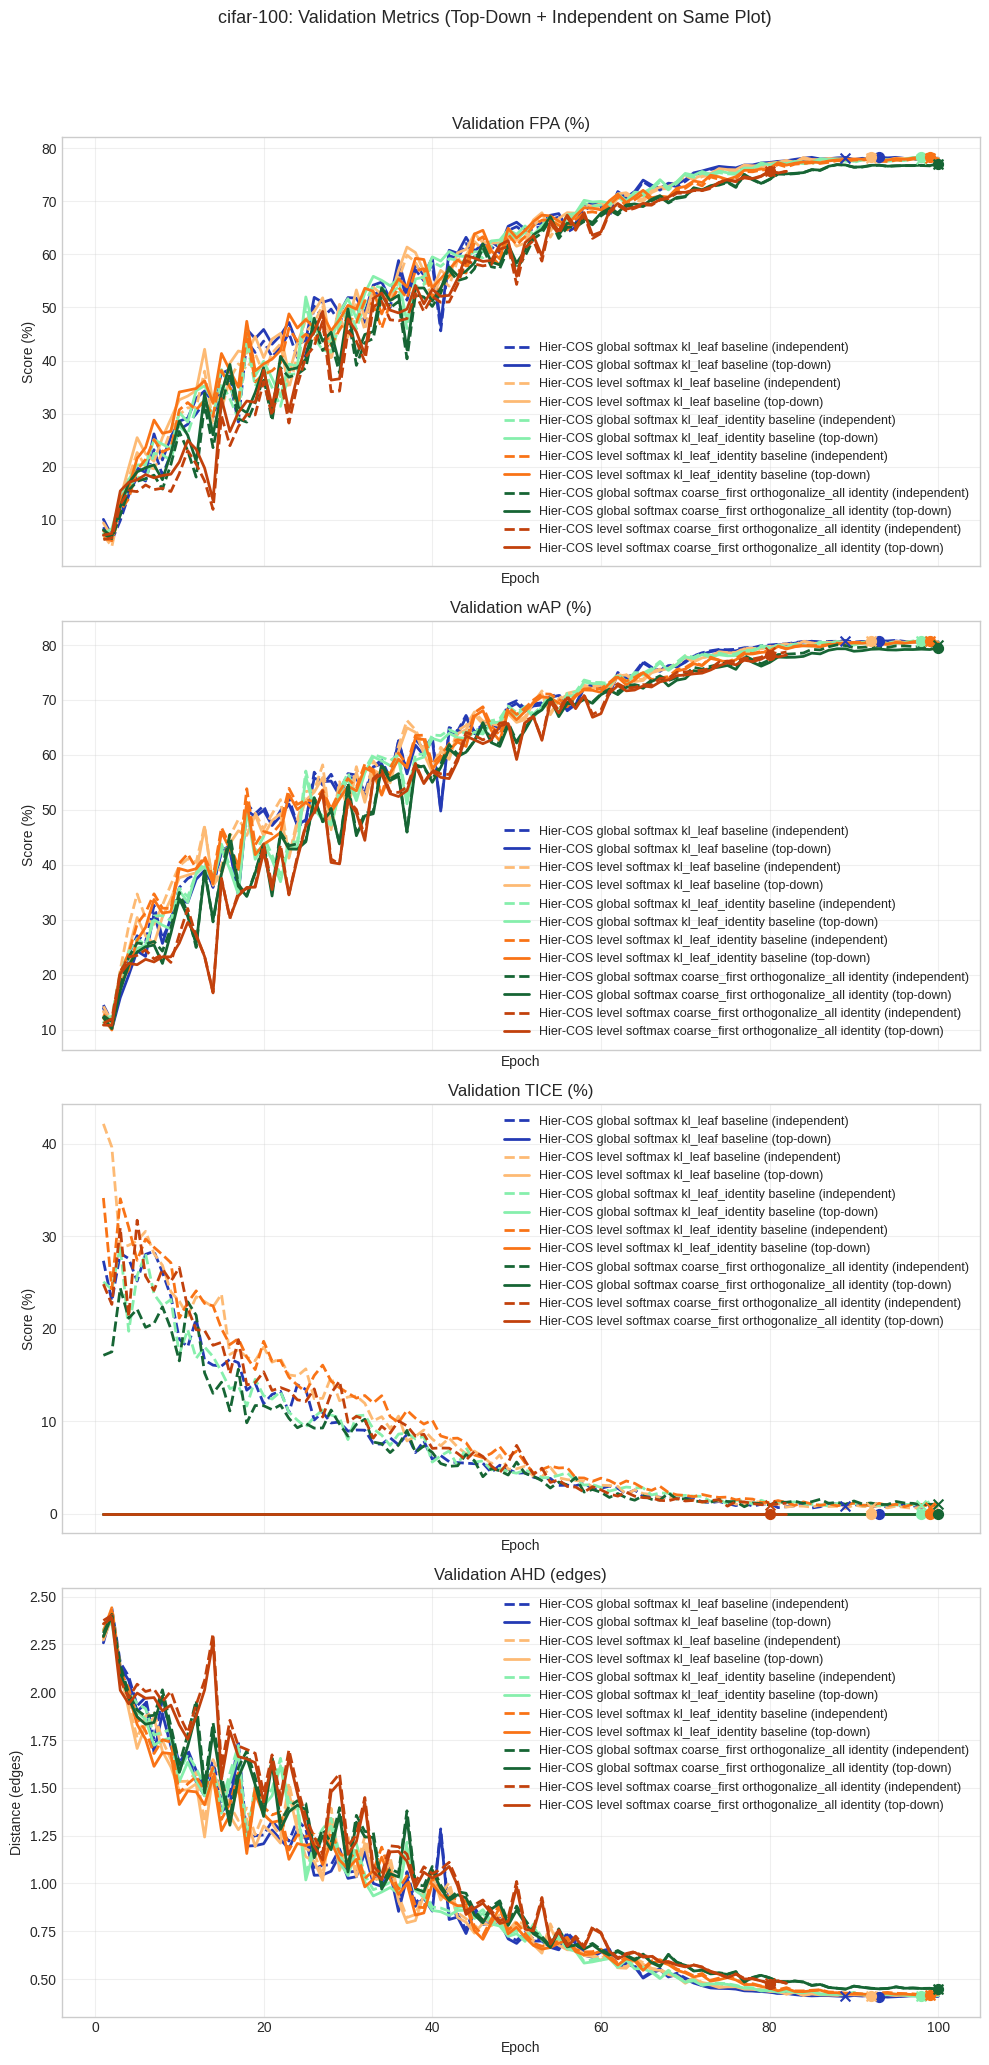

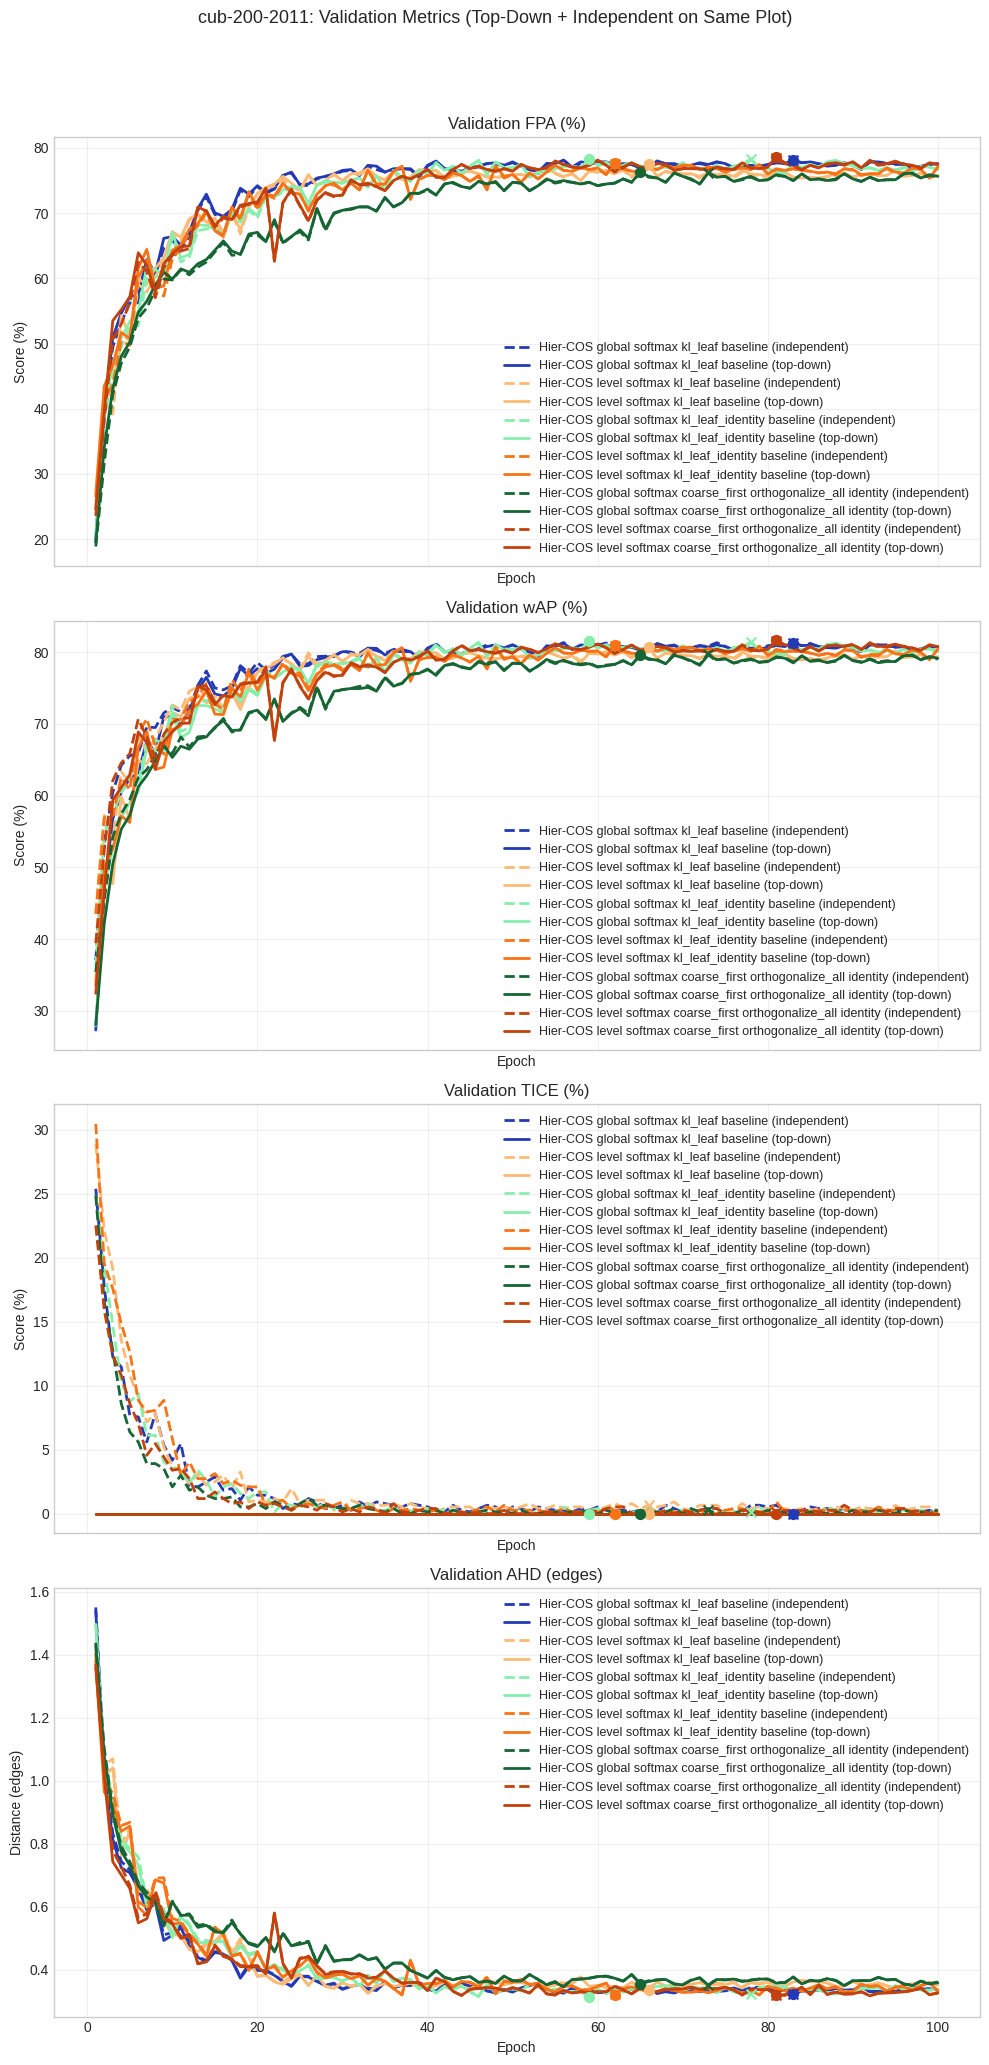

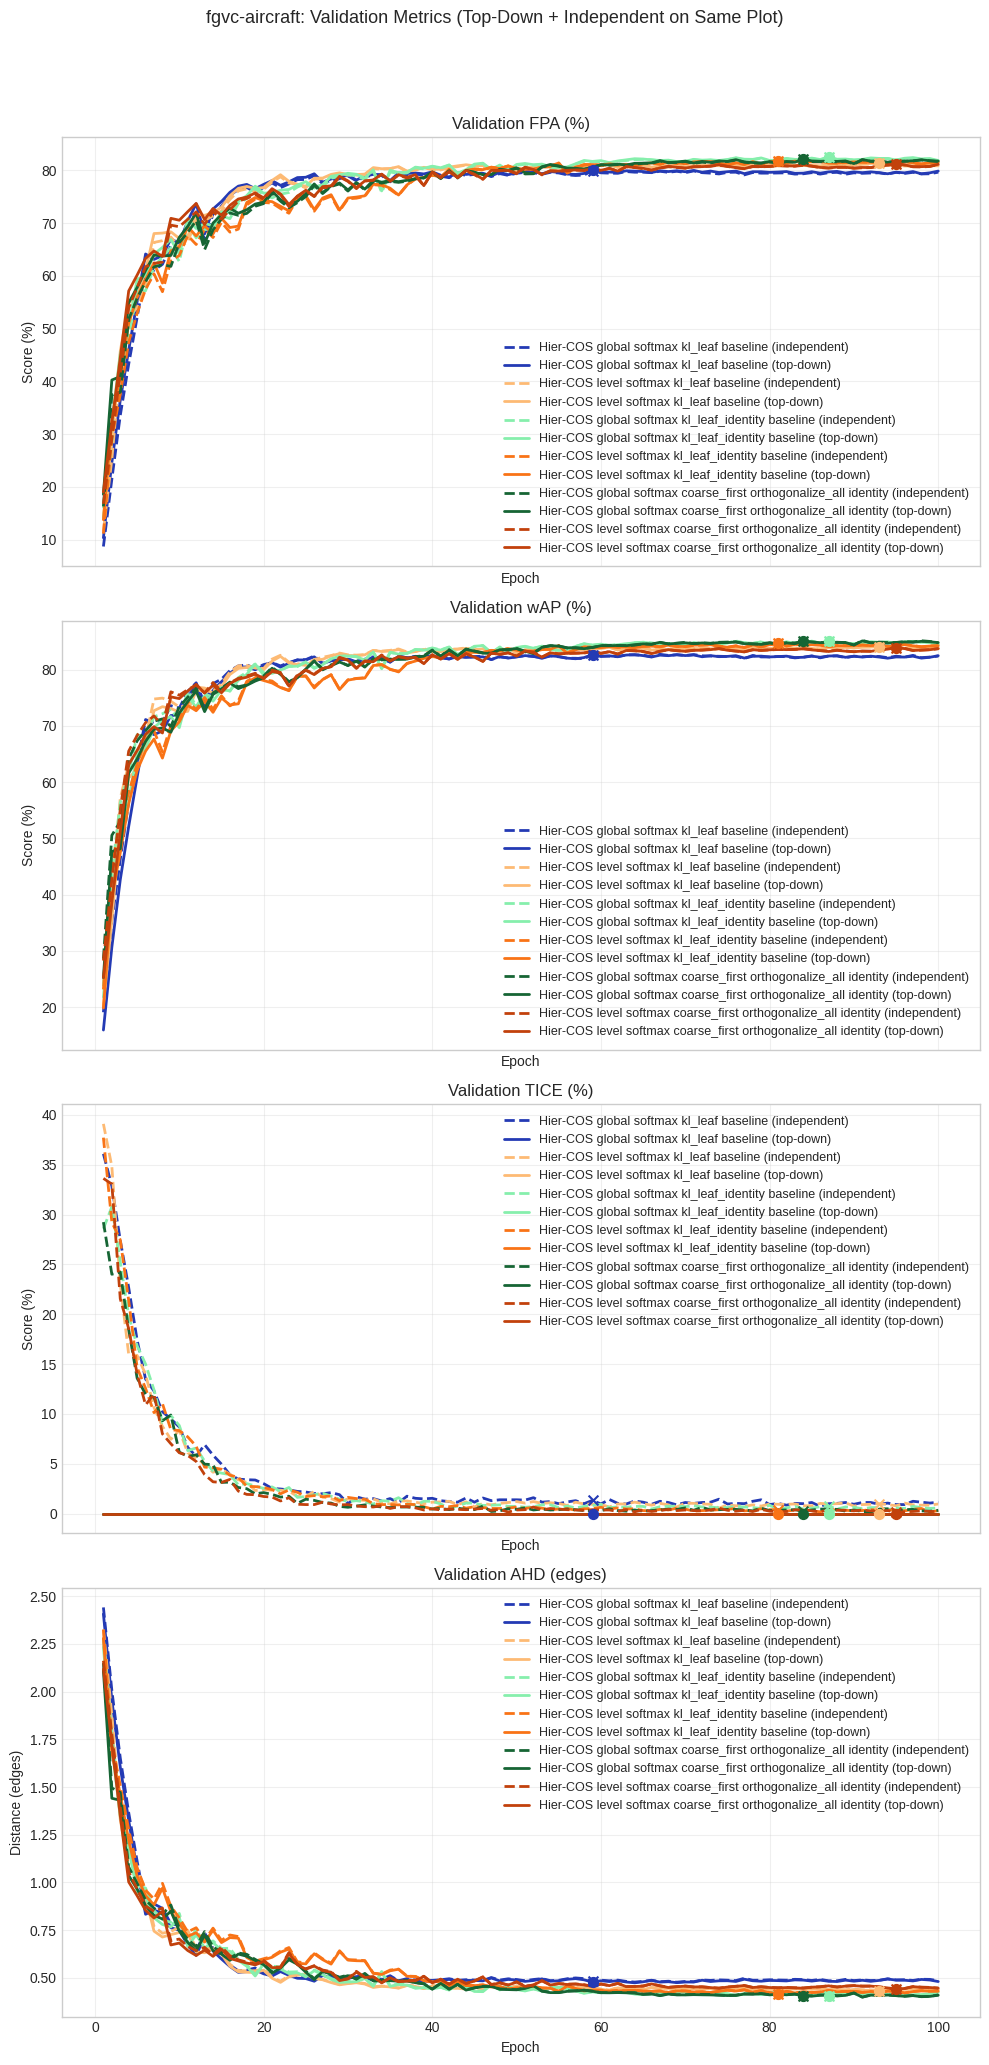

In [14]:
analysis.plot_validation_curves()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate hierarchy-enforcement effects for one run.
- Compare colors at the same line style to compare runs under the same decoding mode.

## Projection Diagnostics (If Available)

This section visualizes projection diagnostics logged in `val_metrics` and `train_metrics` (when available):
- `proj_constraint_alpha`, `proj_constraint_strength`, `proj_temperature`, `proj_mode_intrinsic_soft`

For standard Hier-COS runs these keys may be absent; in that case the section prints a per-dataset skip message.


In [15]:
analysis.plot_projection_diagnostics()


[cifar-100] No projection diagnostics found in selected runs.
[cub-200-2011] No projection diagnostics found in selected runs.
[fgvc-aircraft] No projection diagnostics found in selected runs.


## Training Loss Comparison

This section compares aggregate losses (`total`, `ce`, `reg`, and exact `kl` for `kl_reg`) and exact weighted per-level objectives (`loss_level_*`, when available).


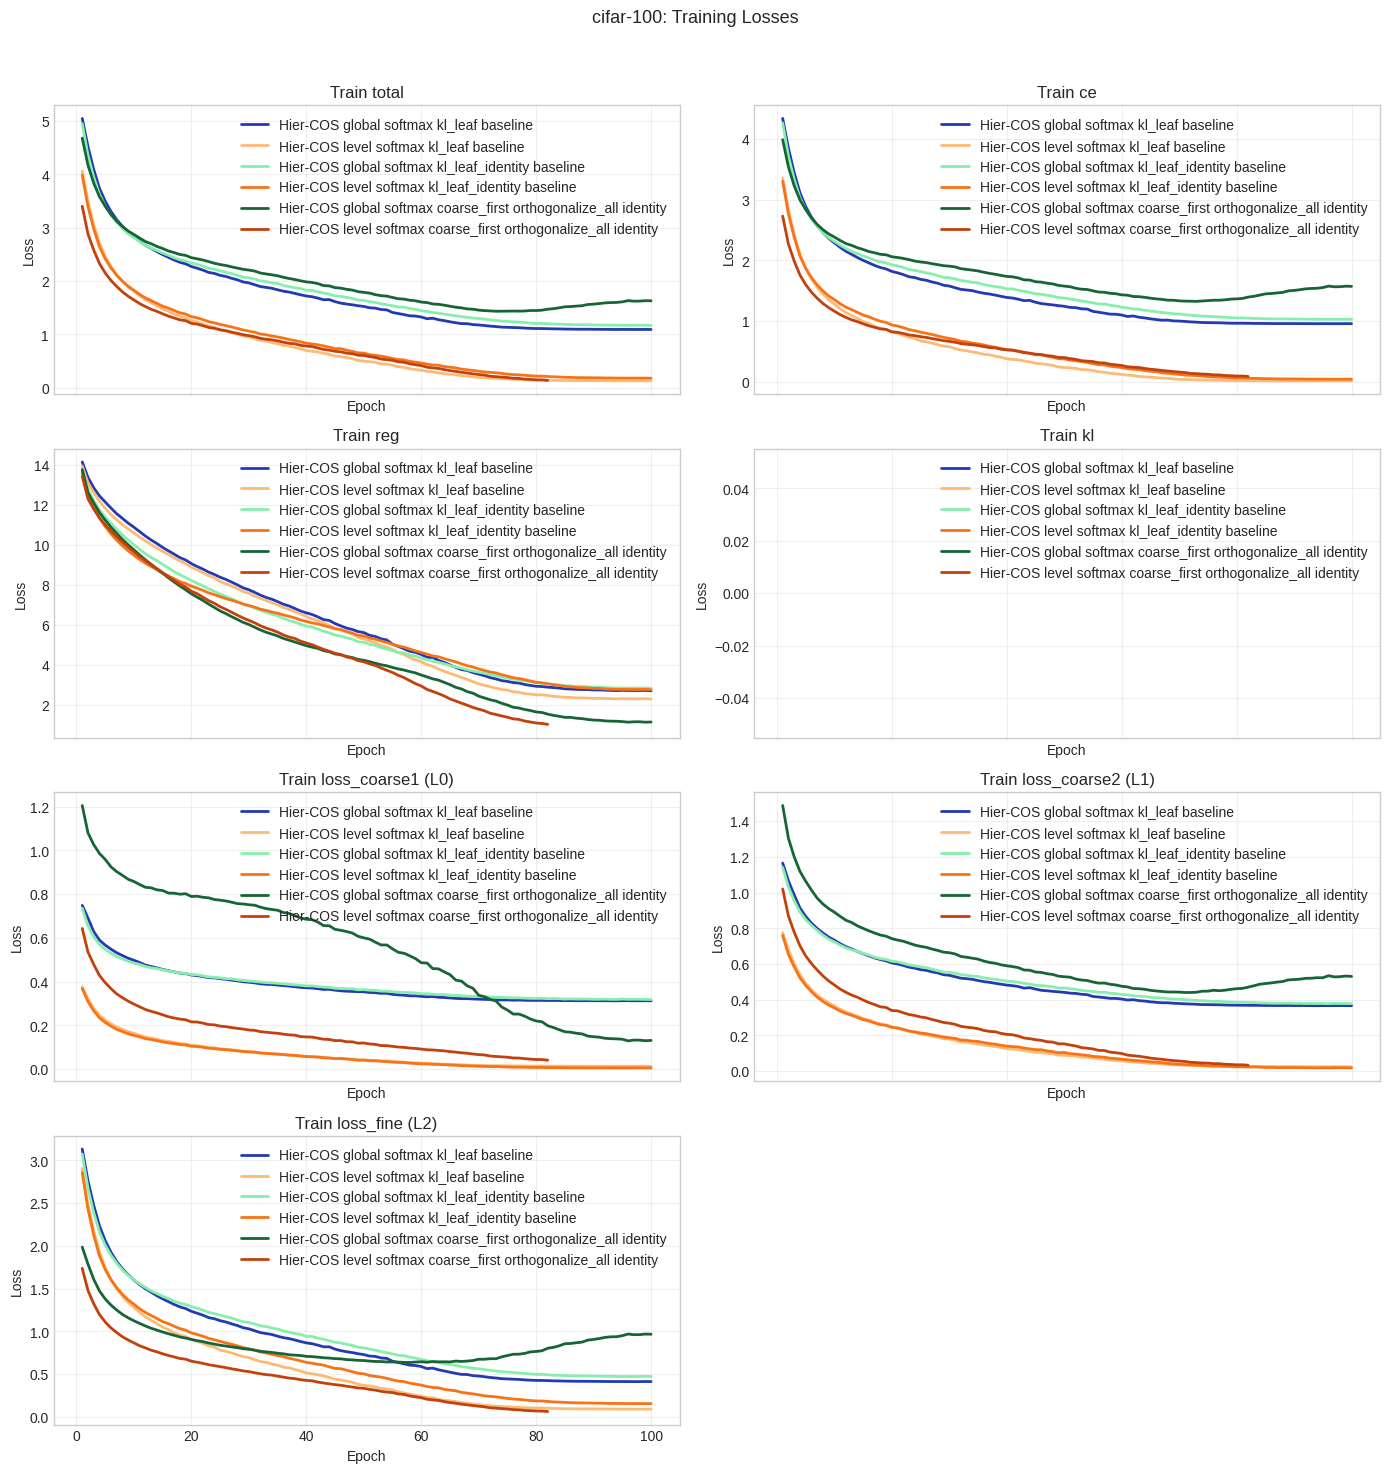

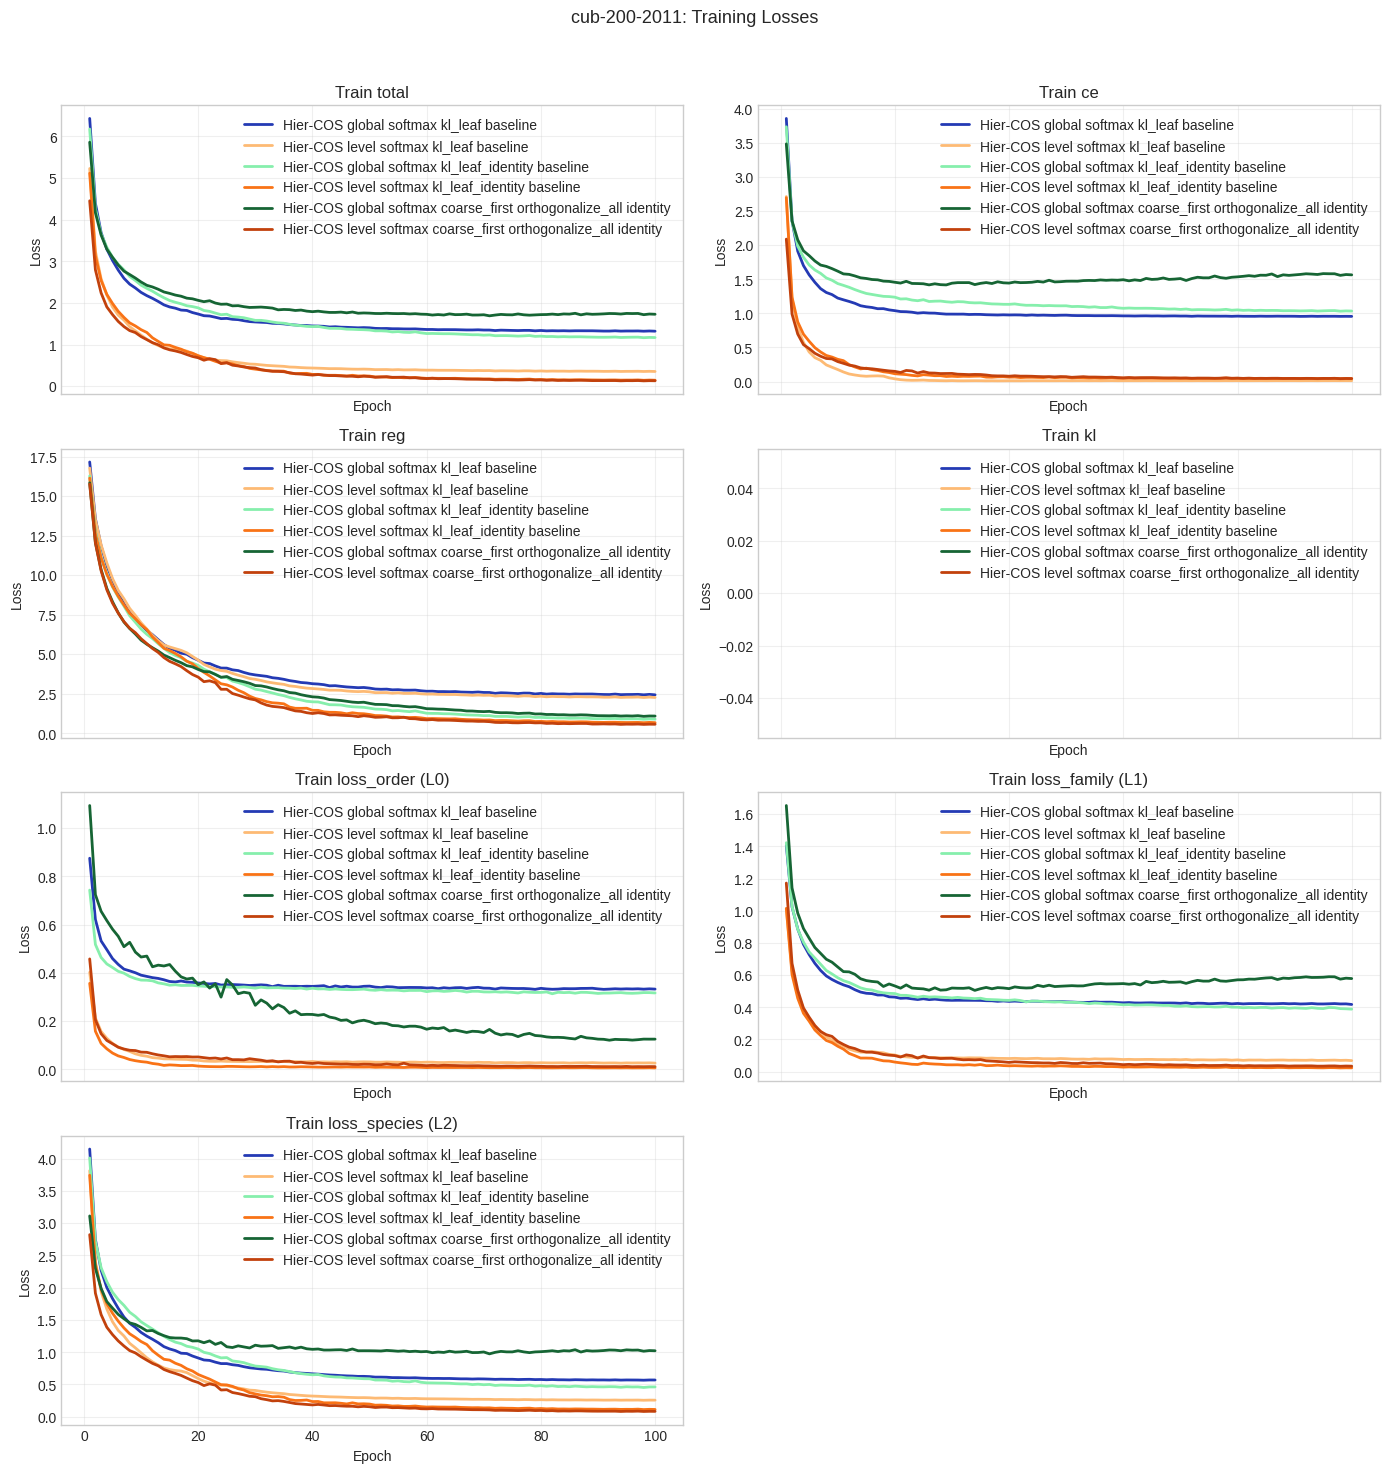

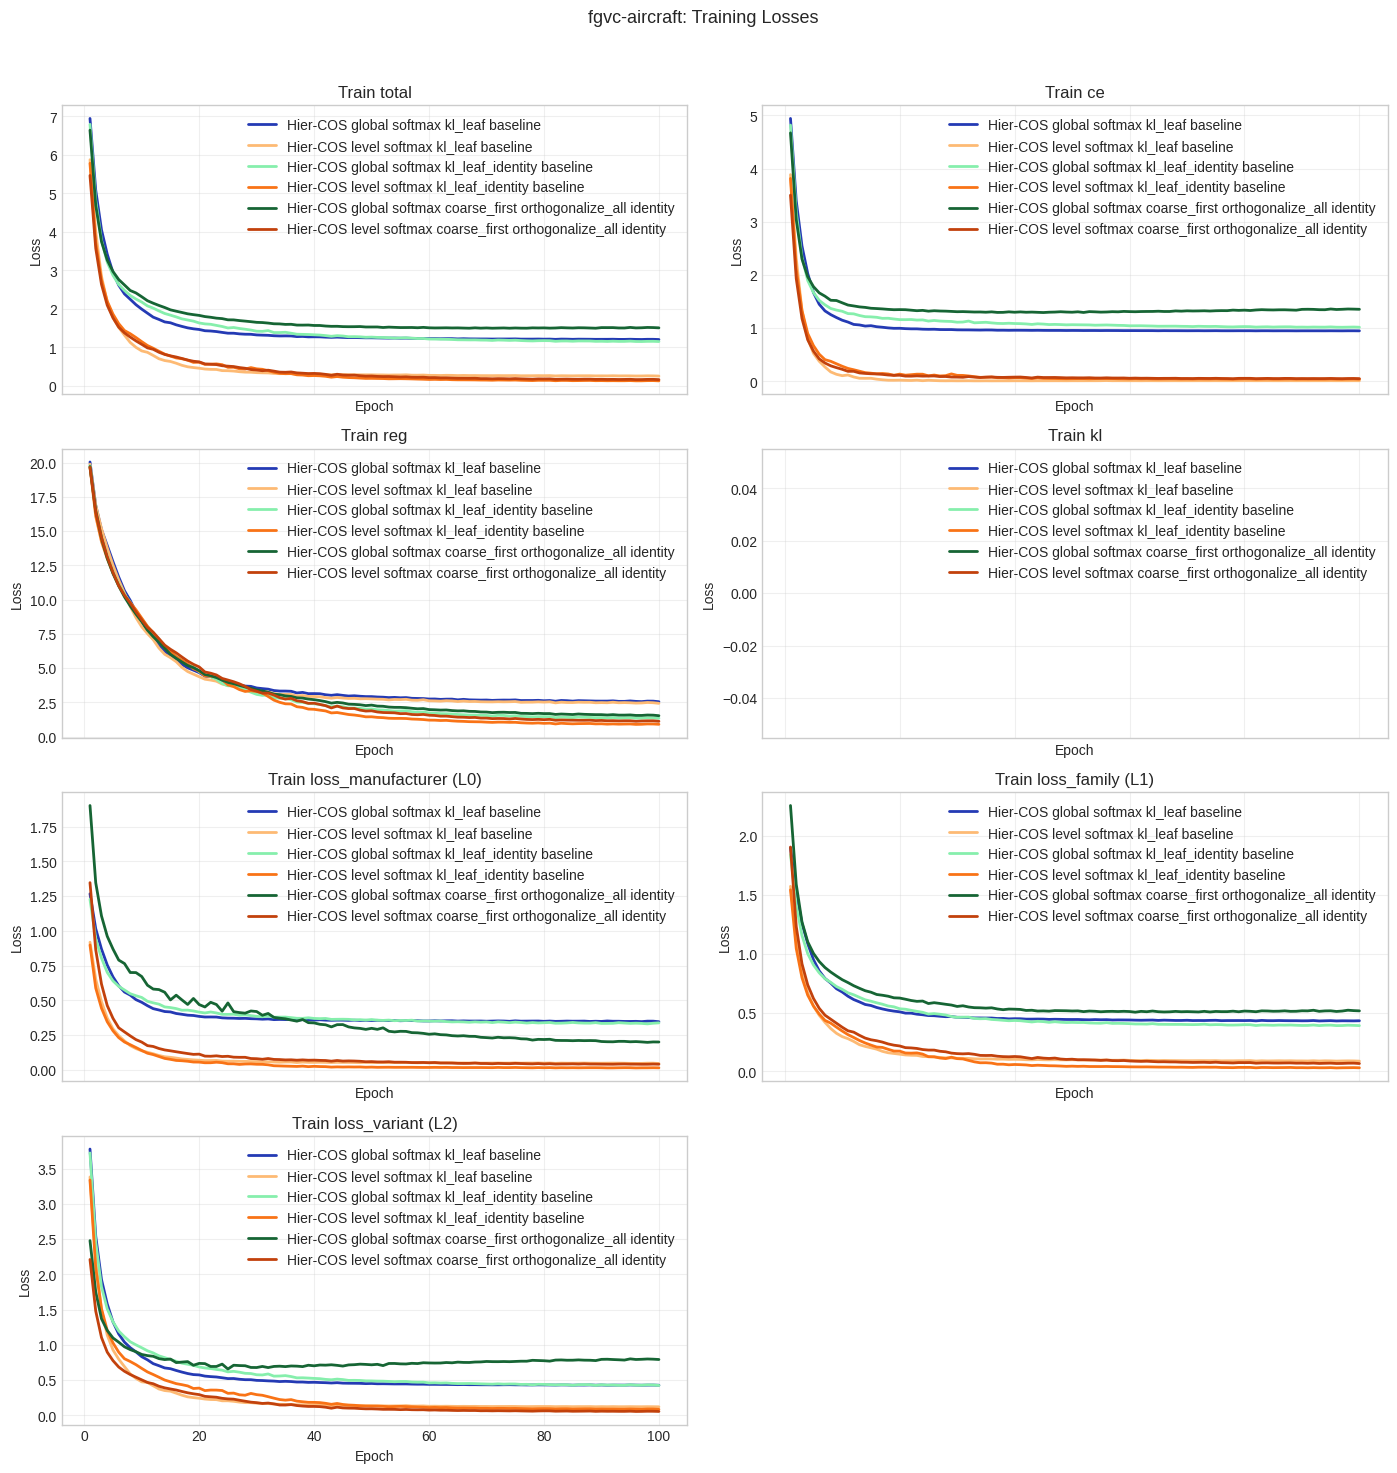

In [16]:
analysis.plot_training_losses(aggregate_loss_keys=['total', 'ce', 'reg', 'kl'])


Interpretation note:
- Lower is better for all loss curves.
- Compare `total` first for optimization behavior, then `loss_level_*` to see where depth-specific training differs.
- If one run has consistently lower shallow-level loss but much higher deep-level loss, expect weaker fine-grained accuracy and path metrics.

## Per-Run Per-Level Training Losses (Per Dataset)

Interpretation note:
- Each chart corresponds to one selected run in its dataset section.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).



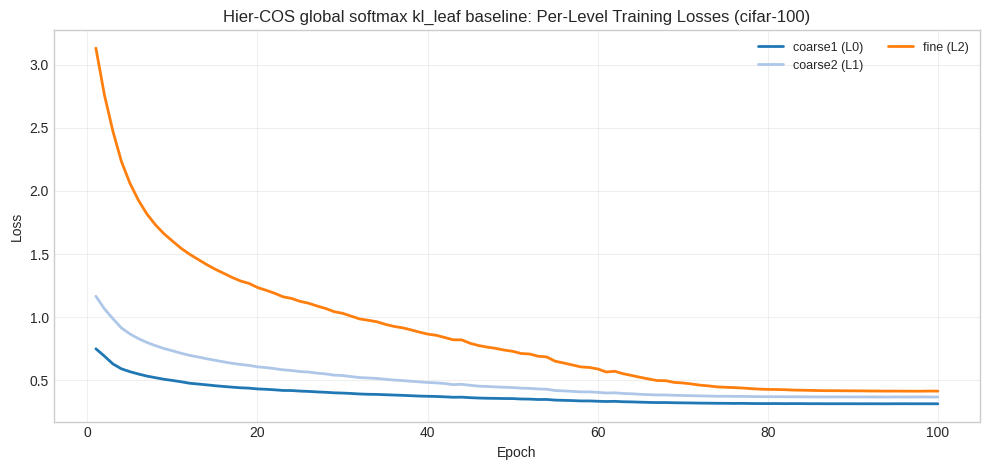

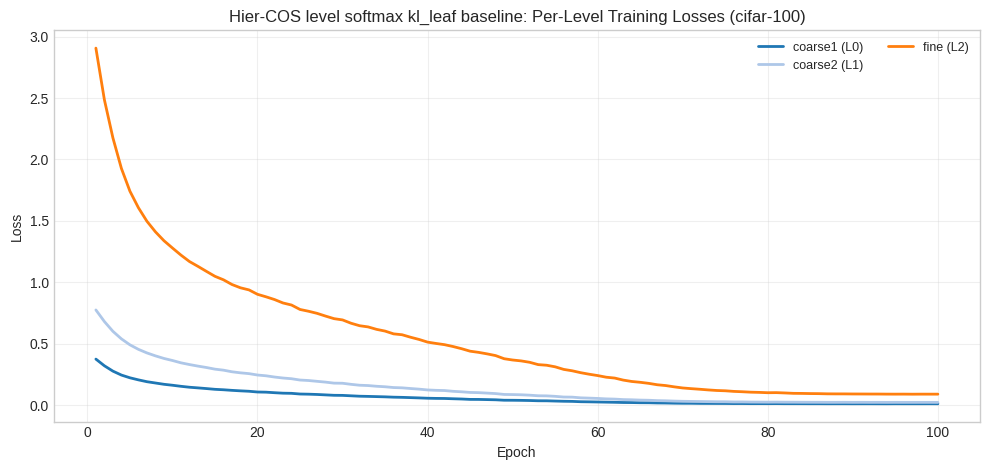

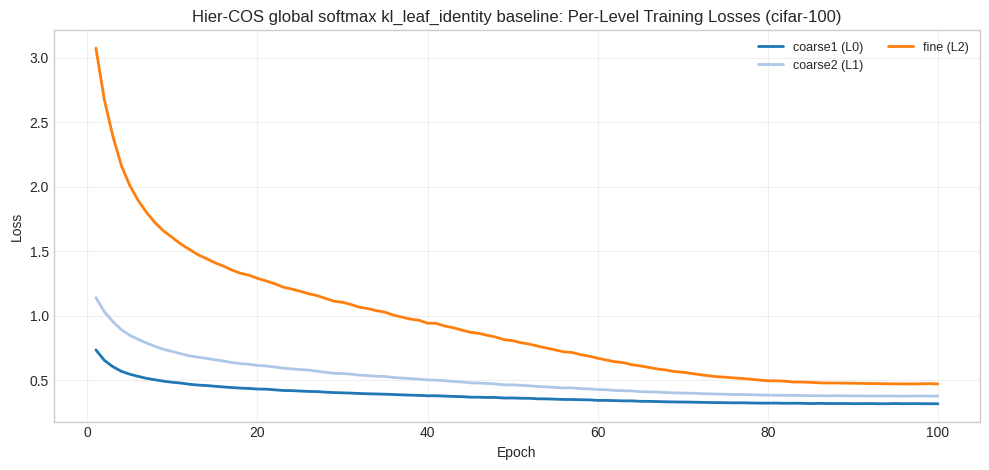

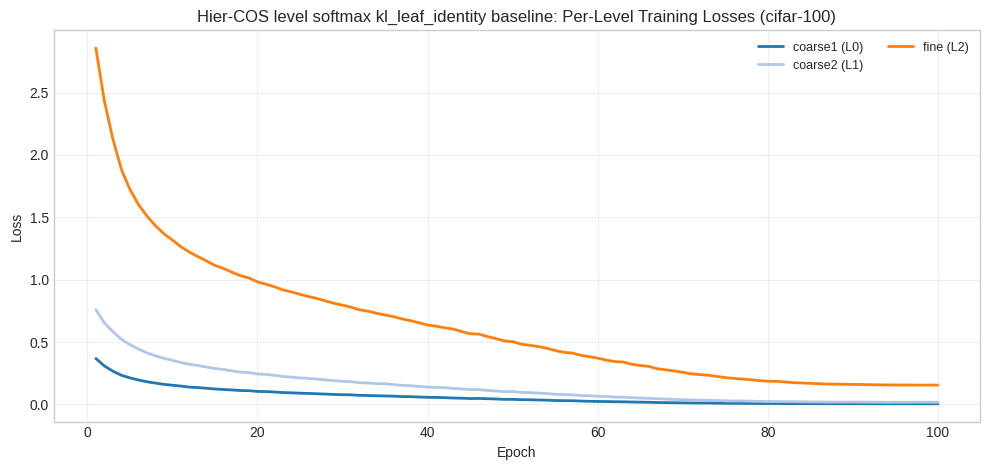

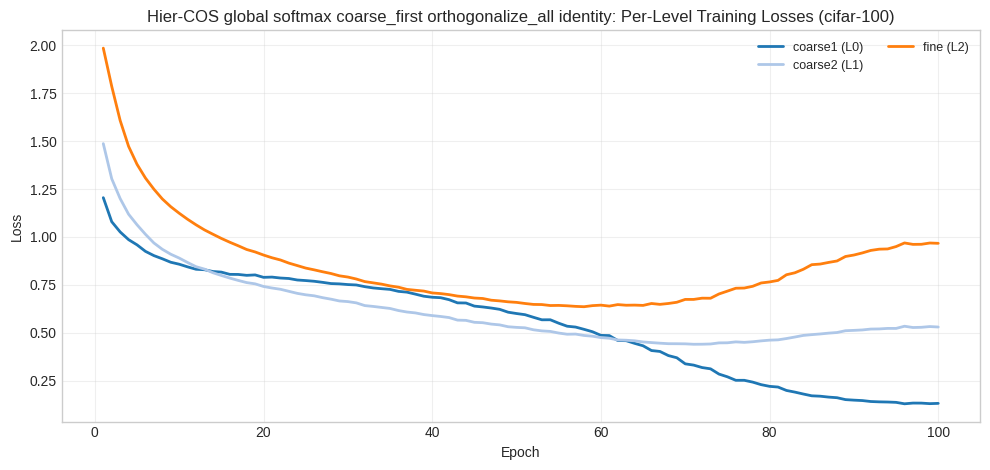

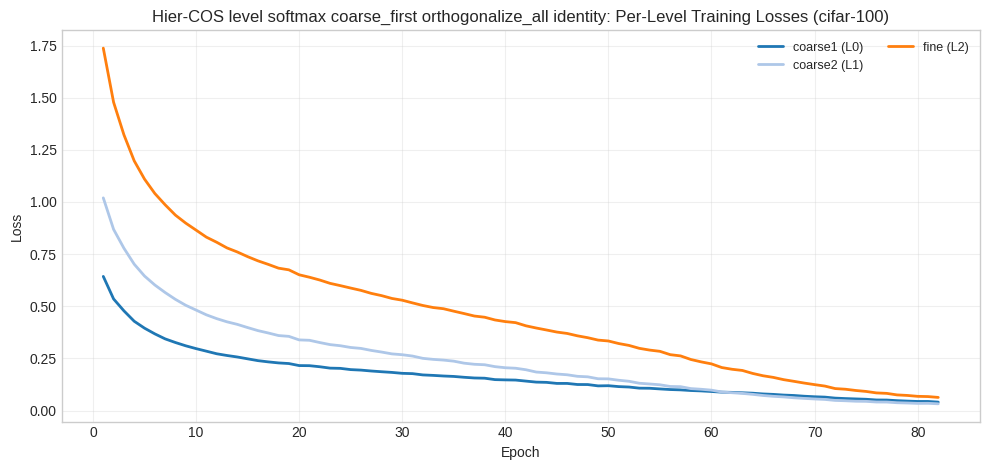

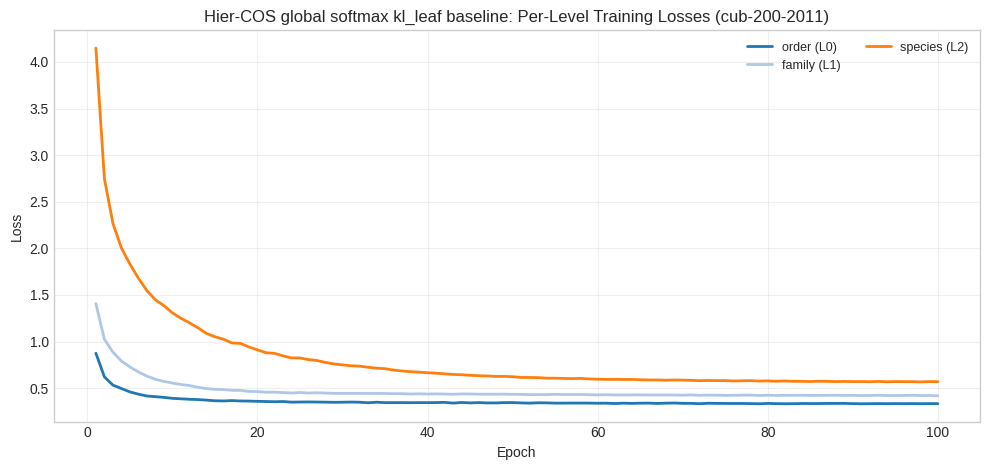

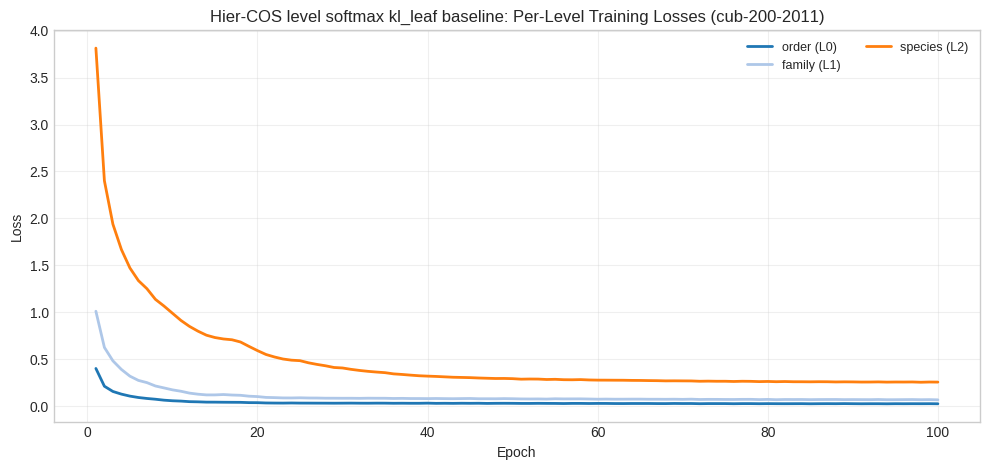

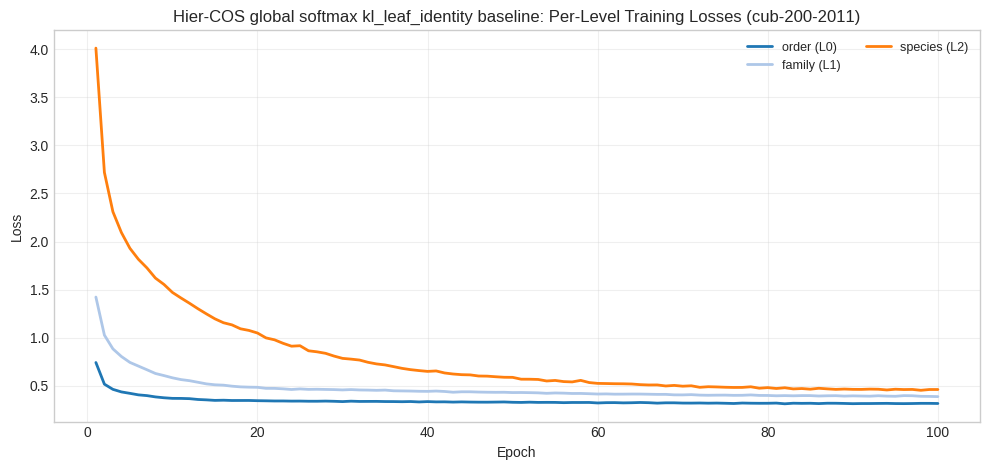

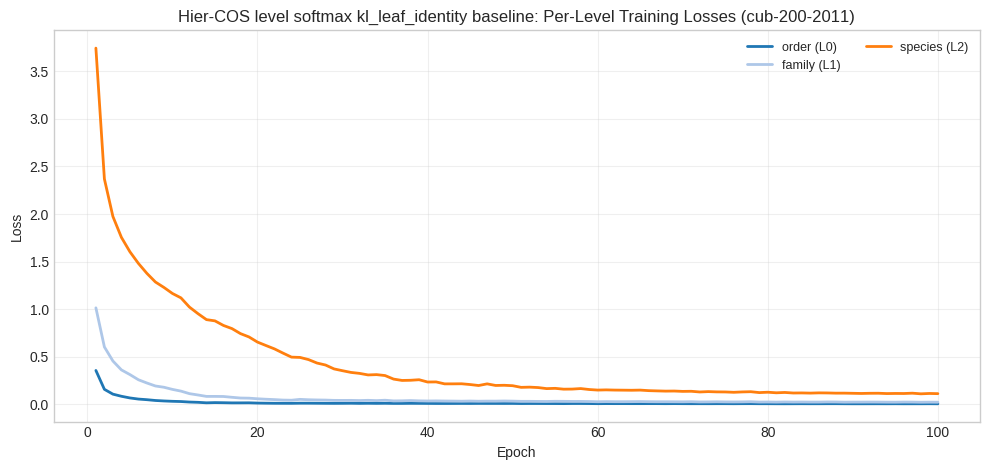

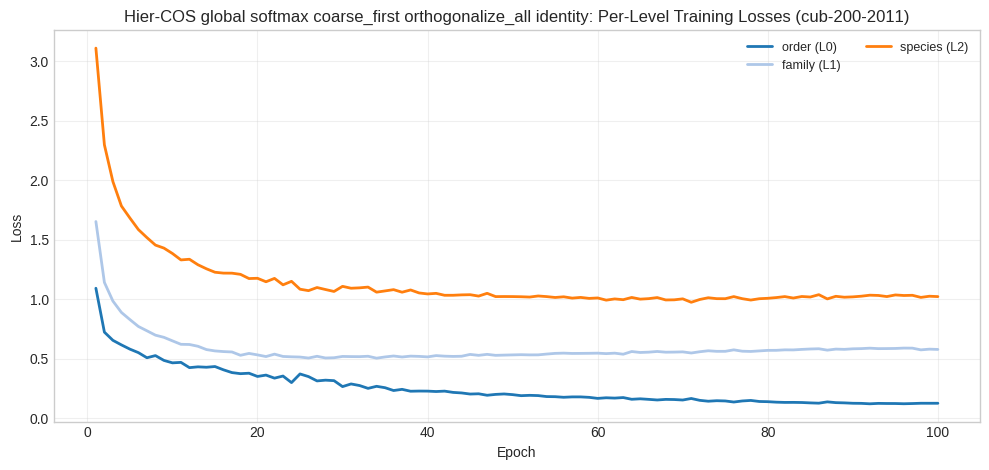

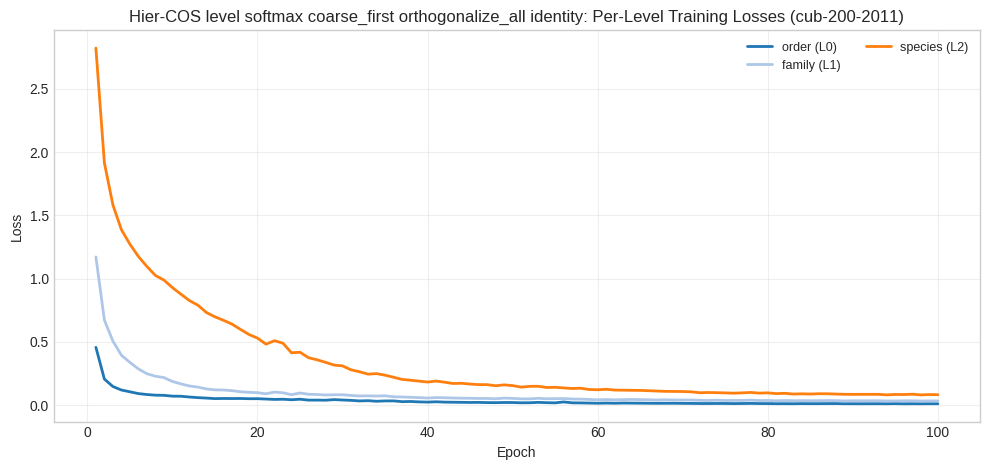

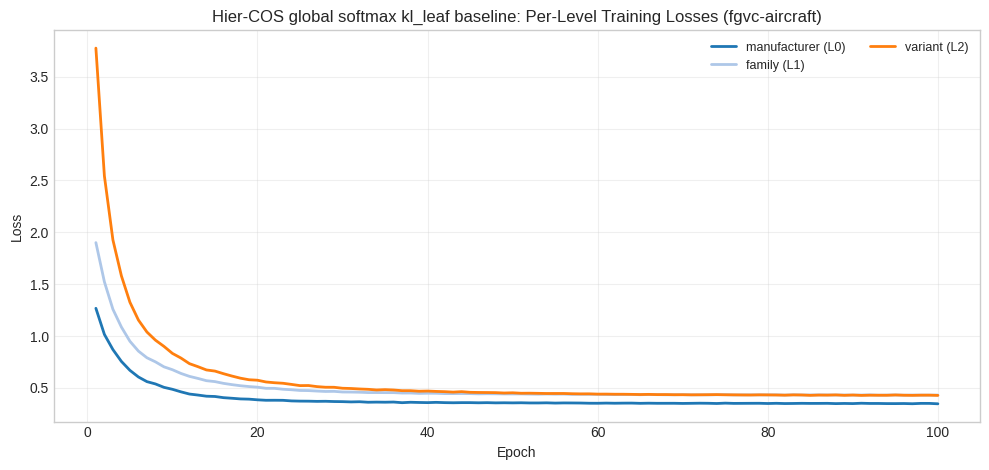

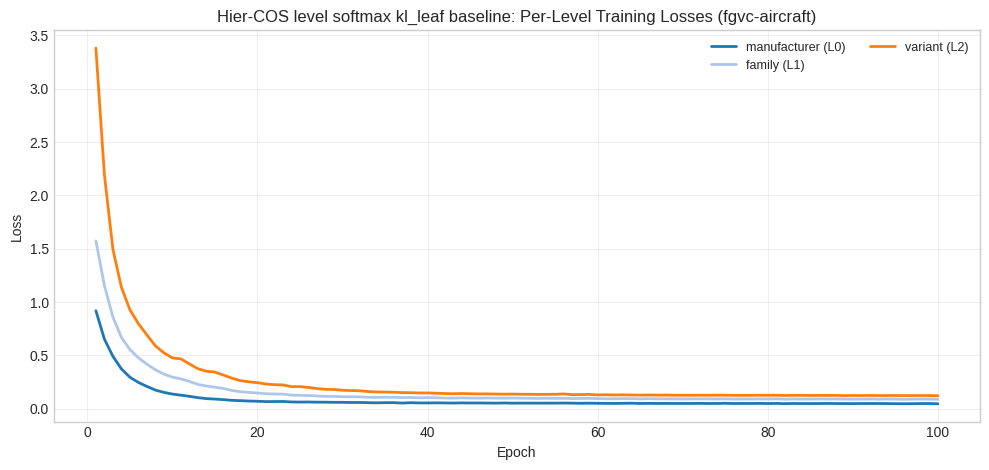

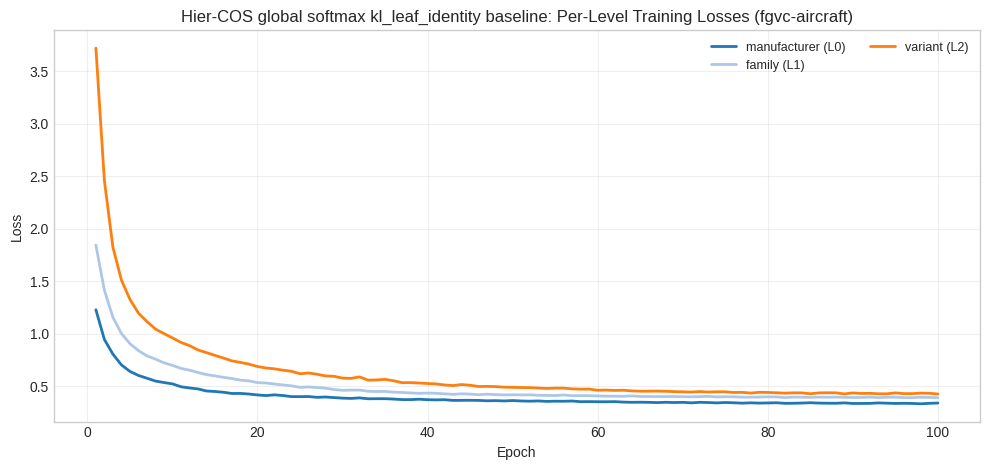

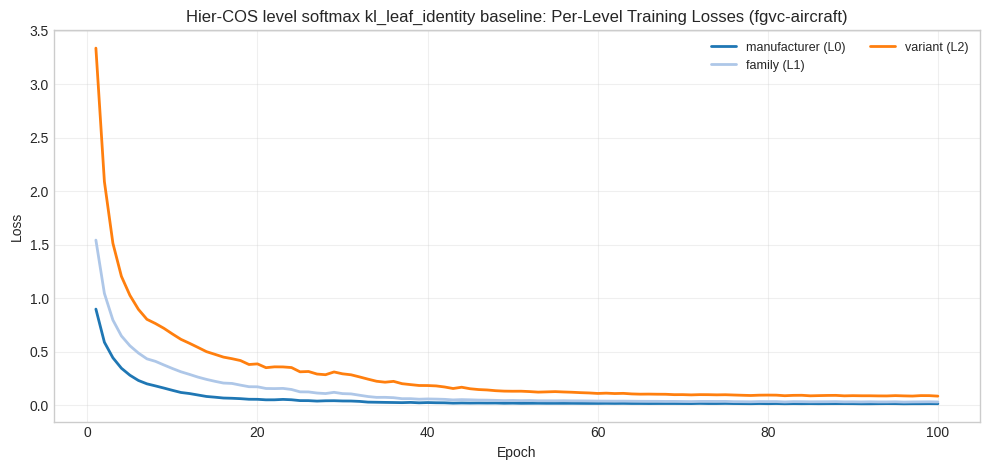

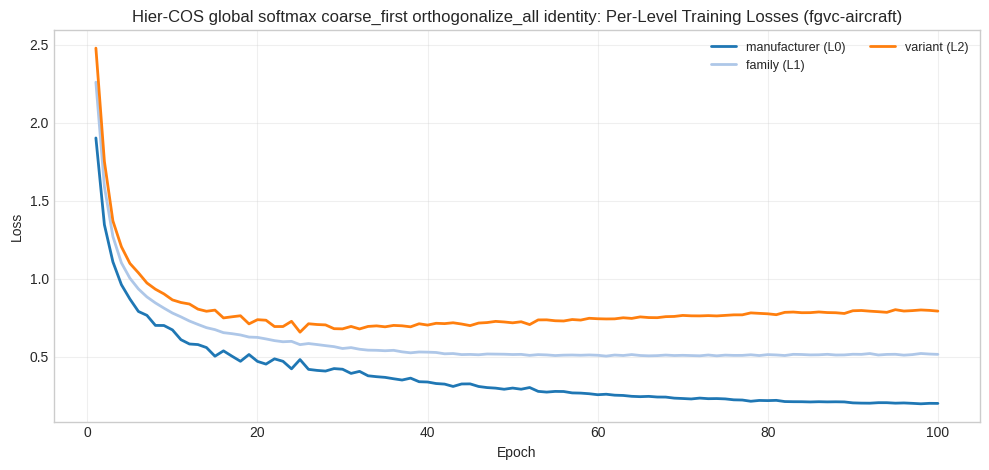

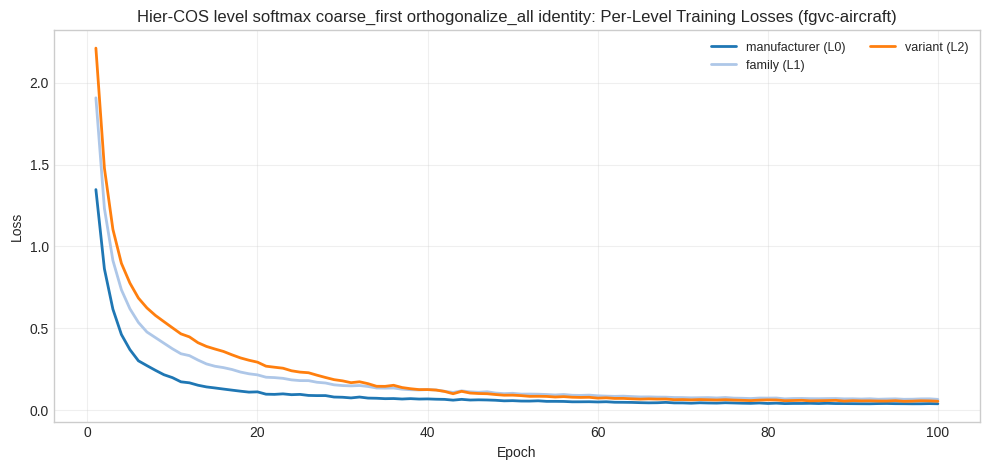

In [17]:
analysis.plot_per_run_per_level_training_losses()


## Gradient Diagnostics (Train)

This section visualizes trunk-based gradient/parameter metrics and optional projection diagnostics stored in `train_metrics` for each epoch.

For Hier-COS, many of these metrics are available only in CE/diagnostic-focused runs. If unavailable, corresponding plots are skipped automatically.


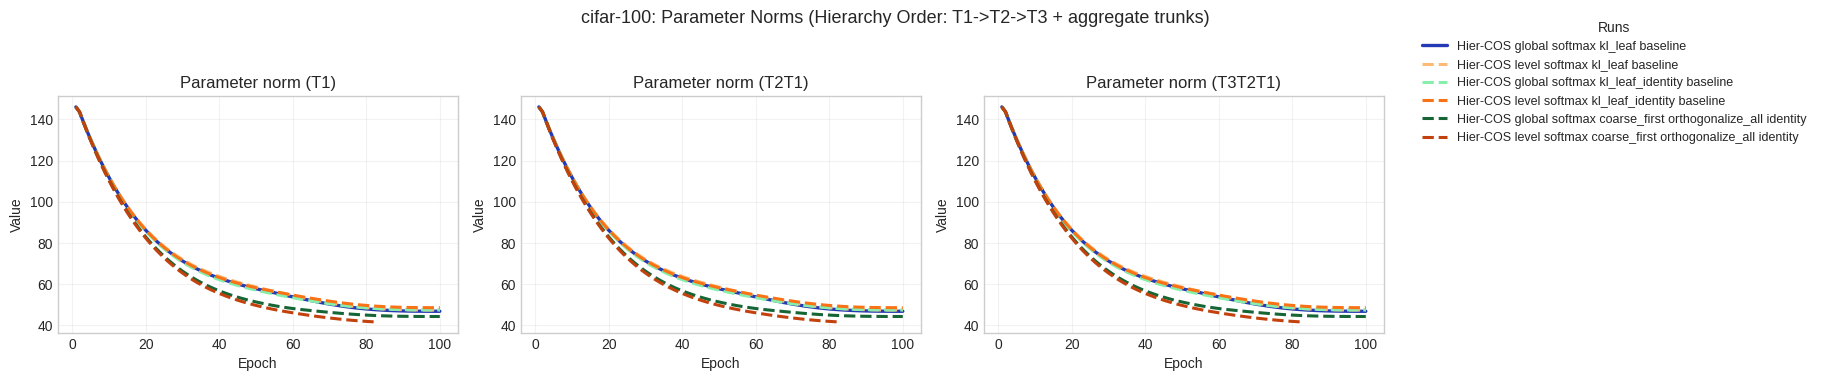

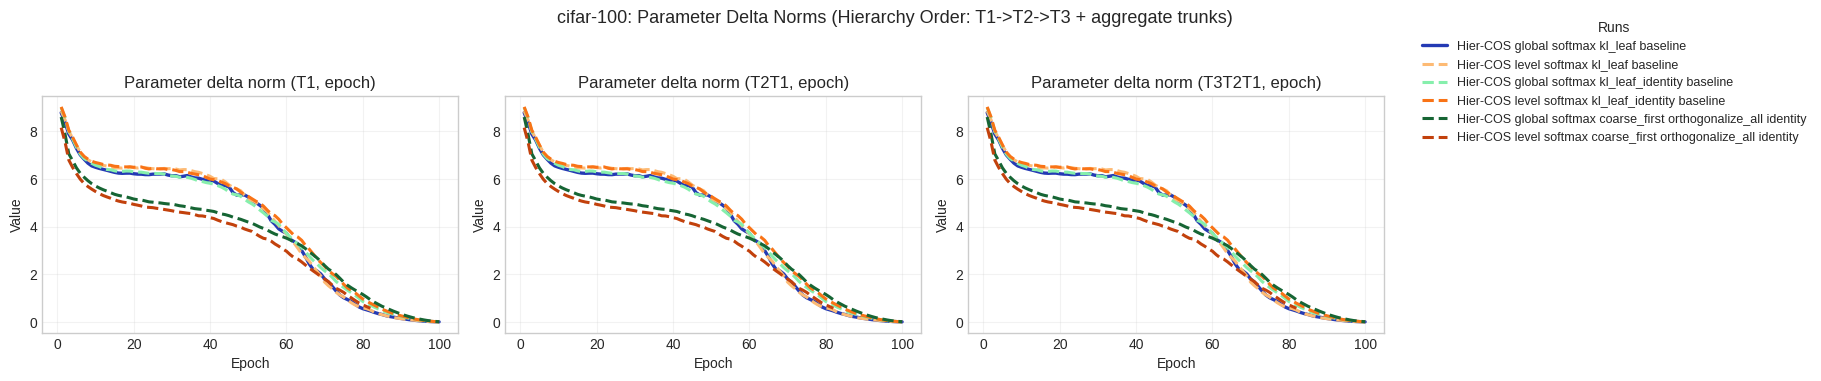

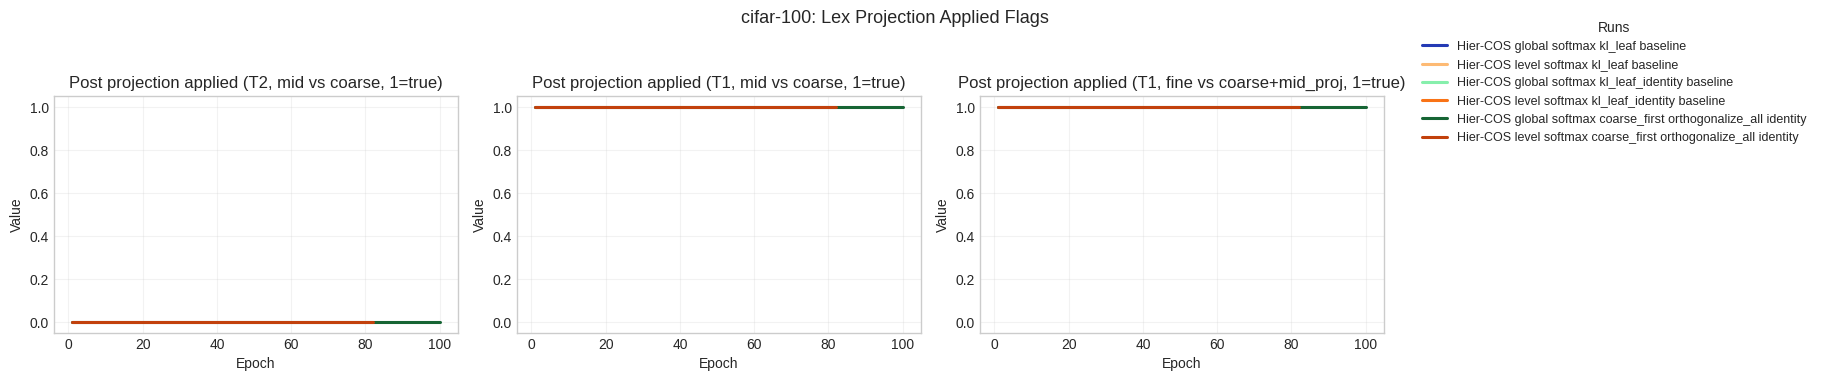

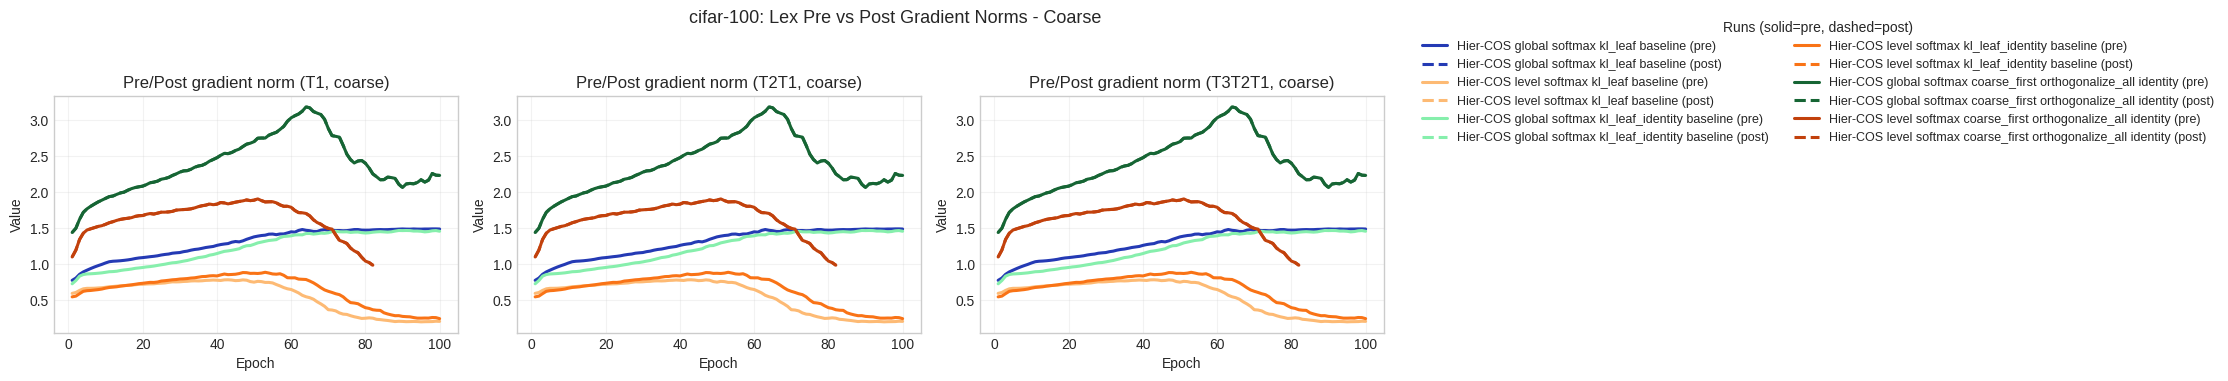

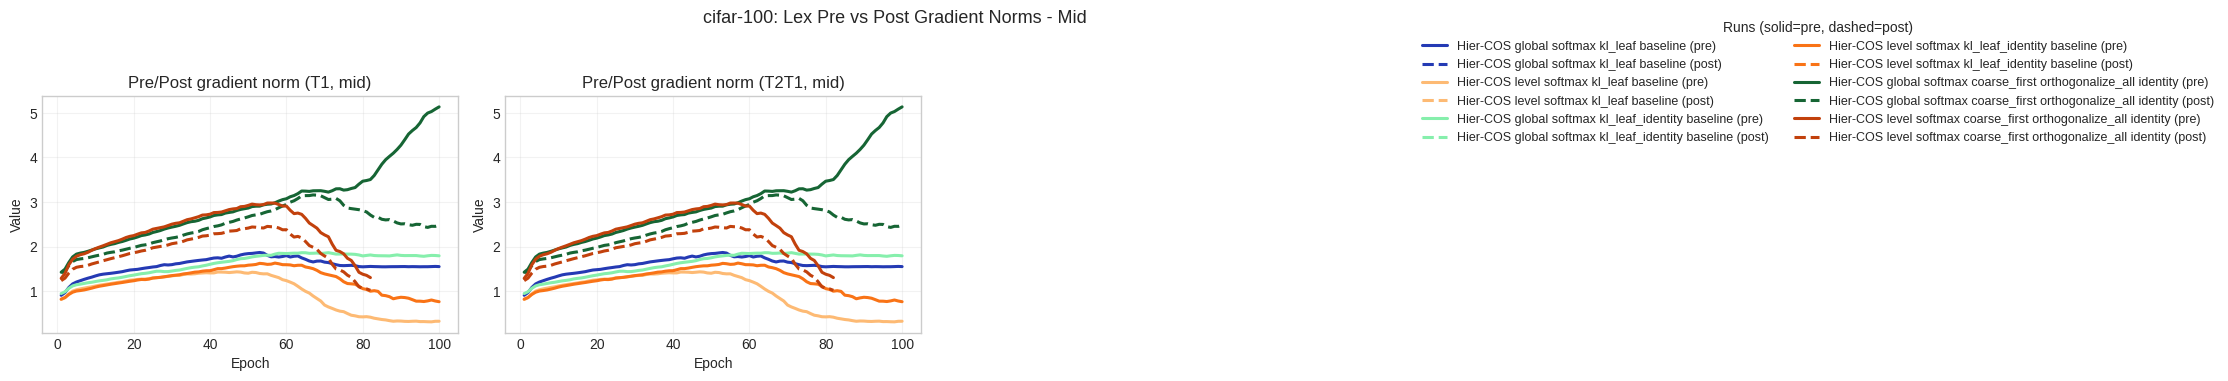

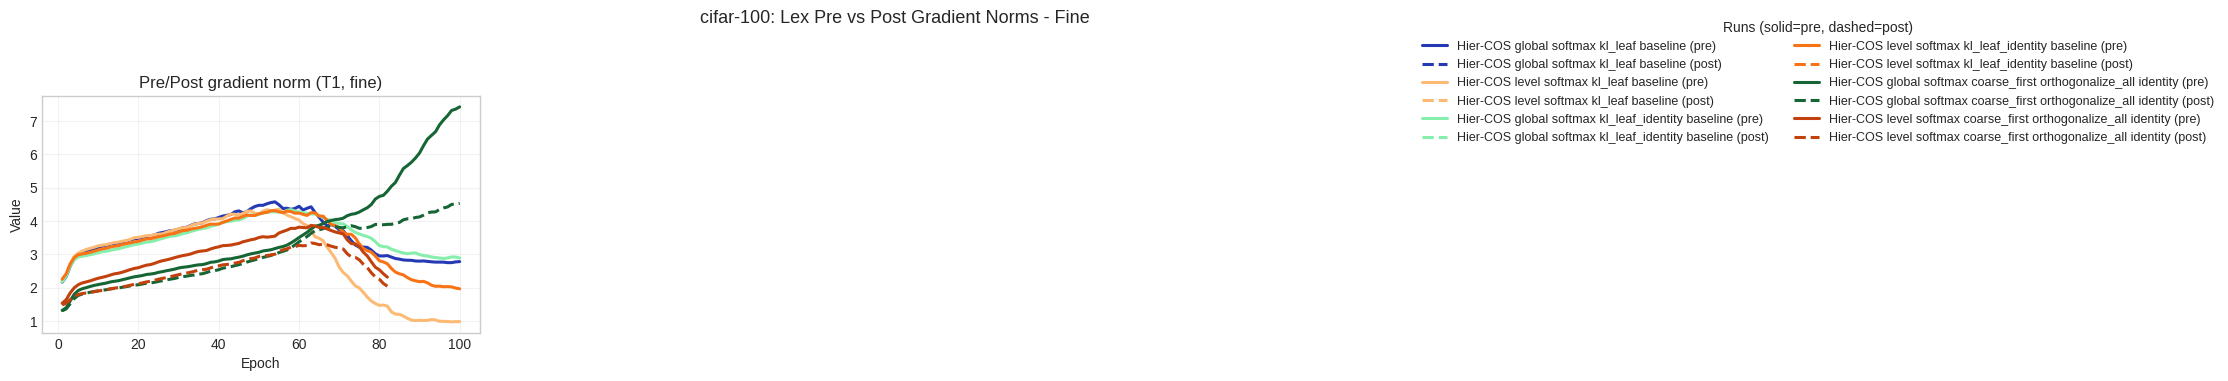

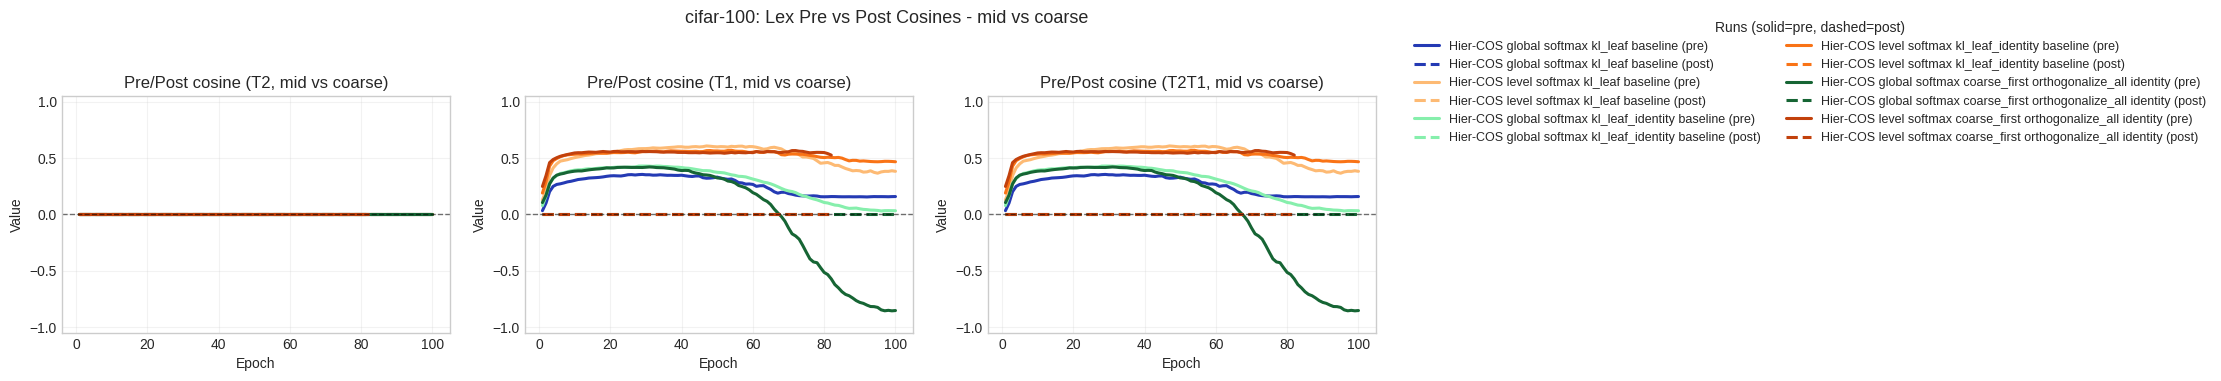

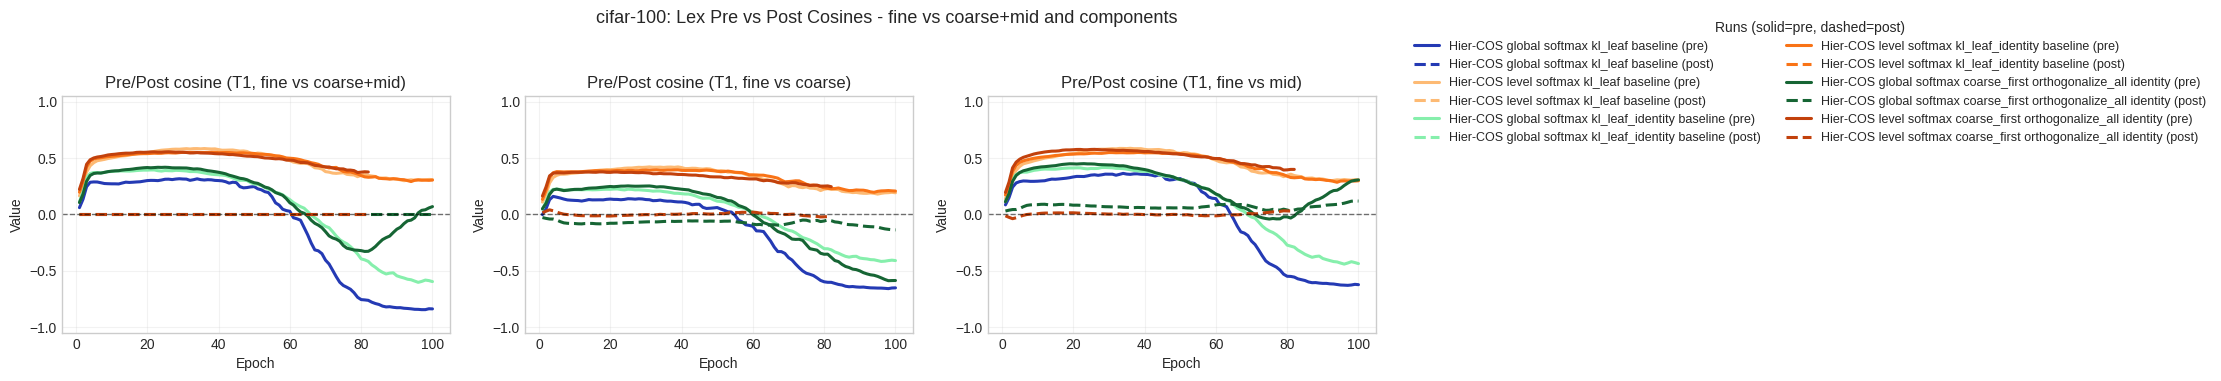

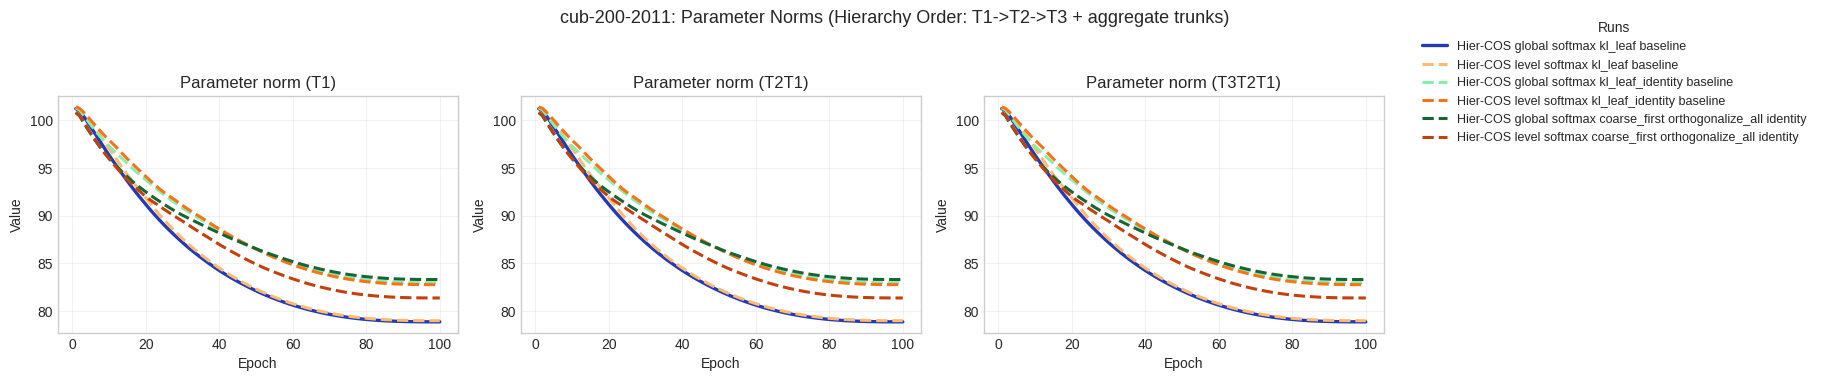

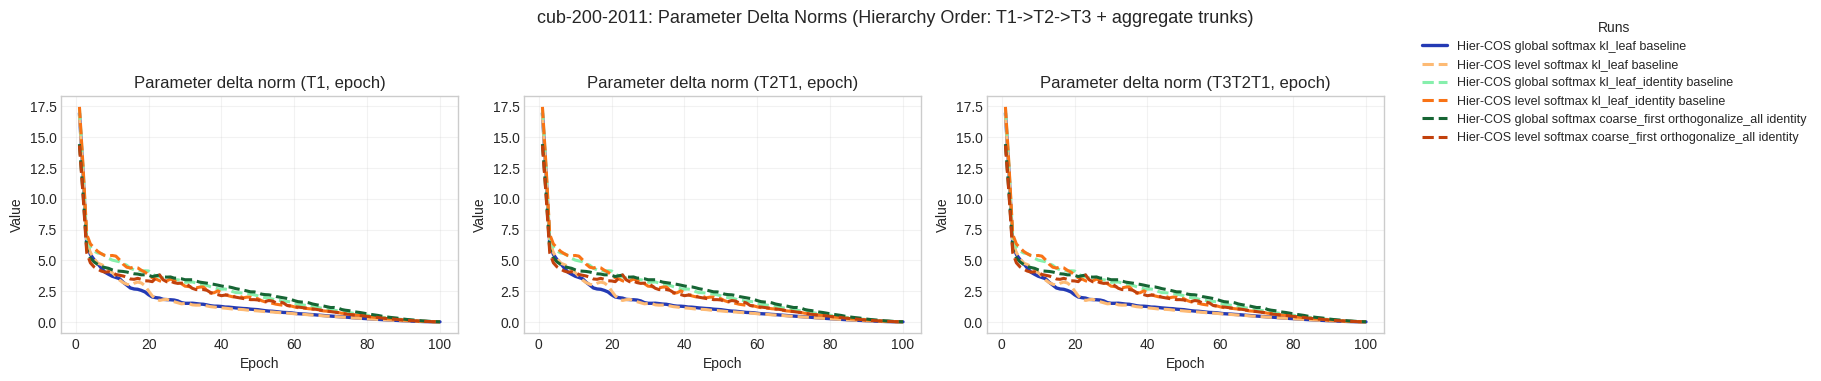

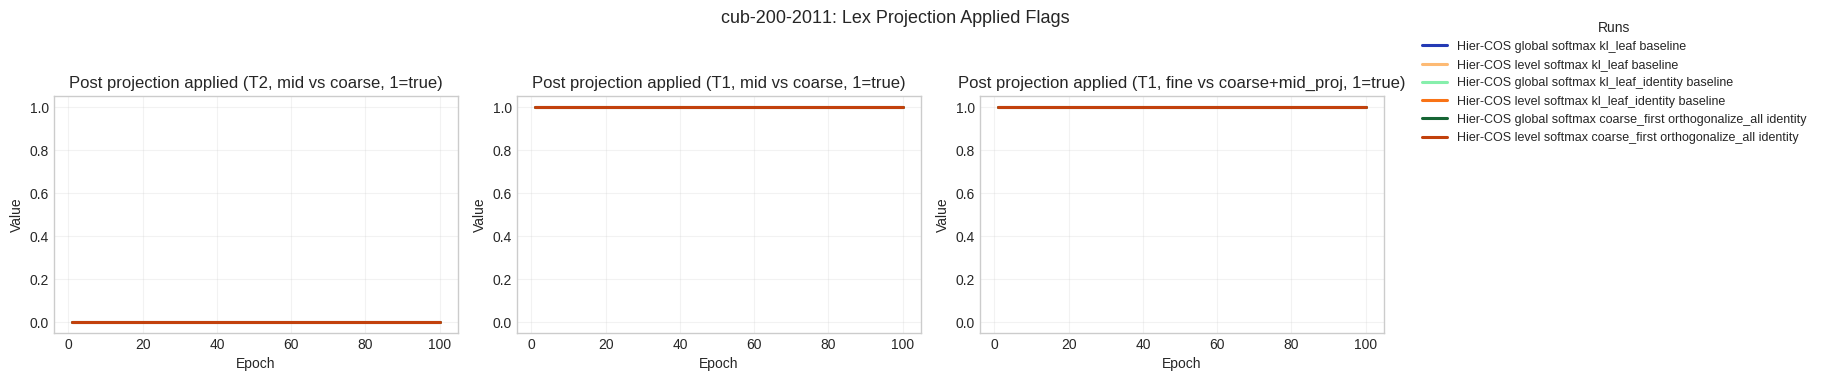

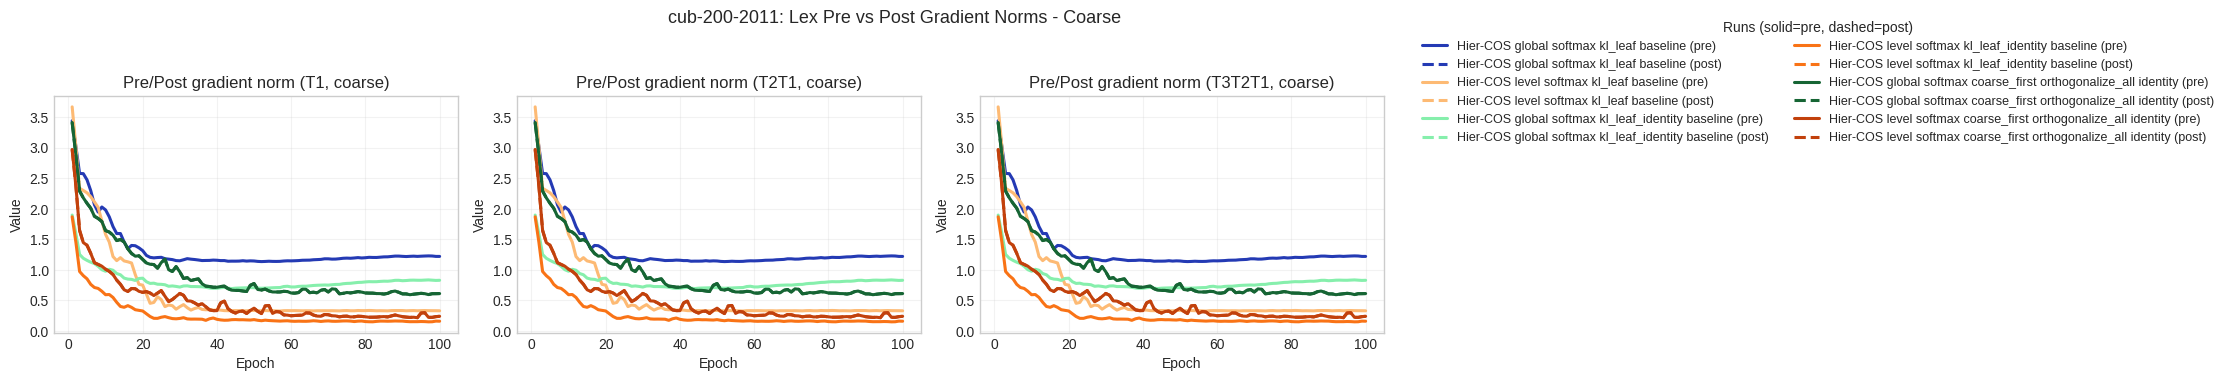

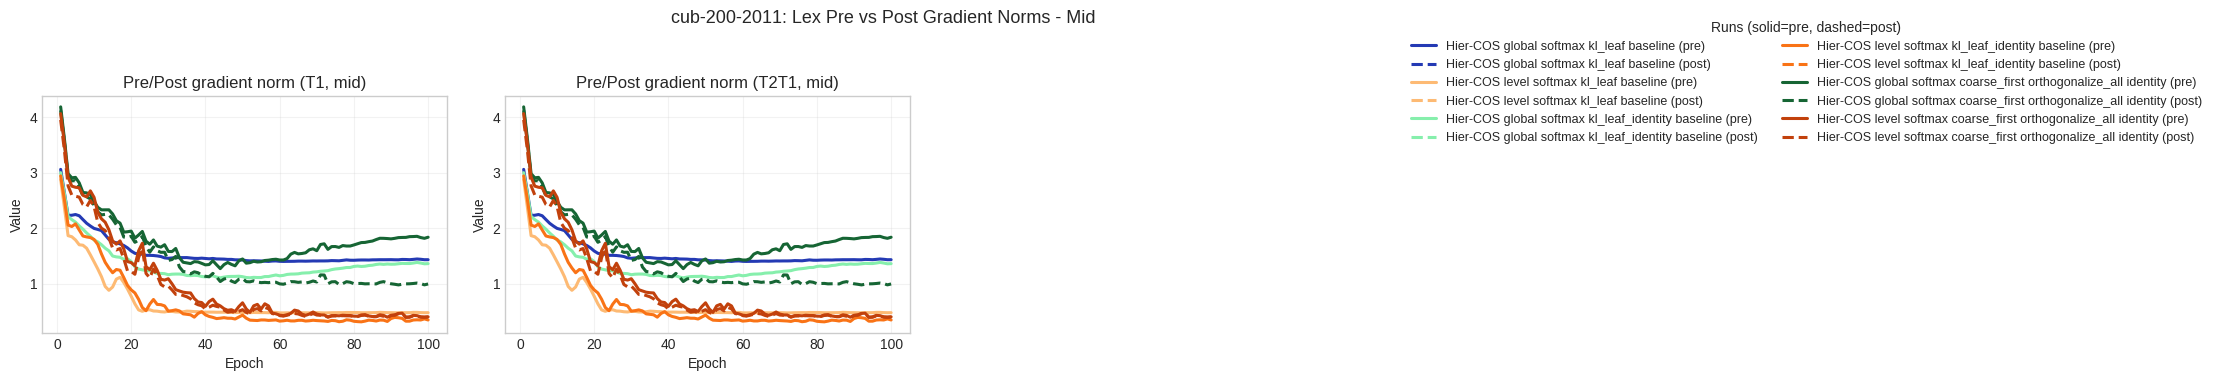

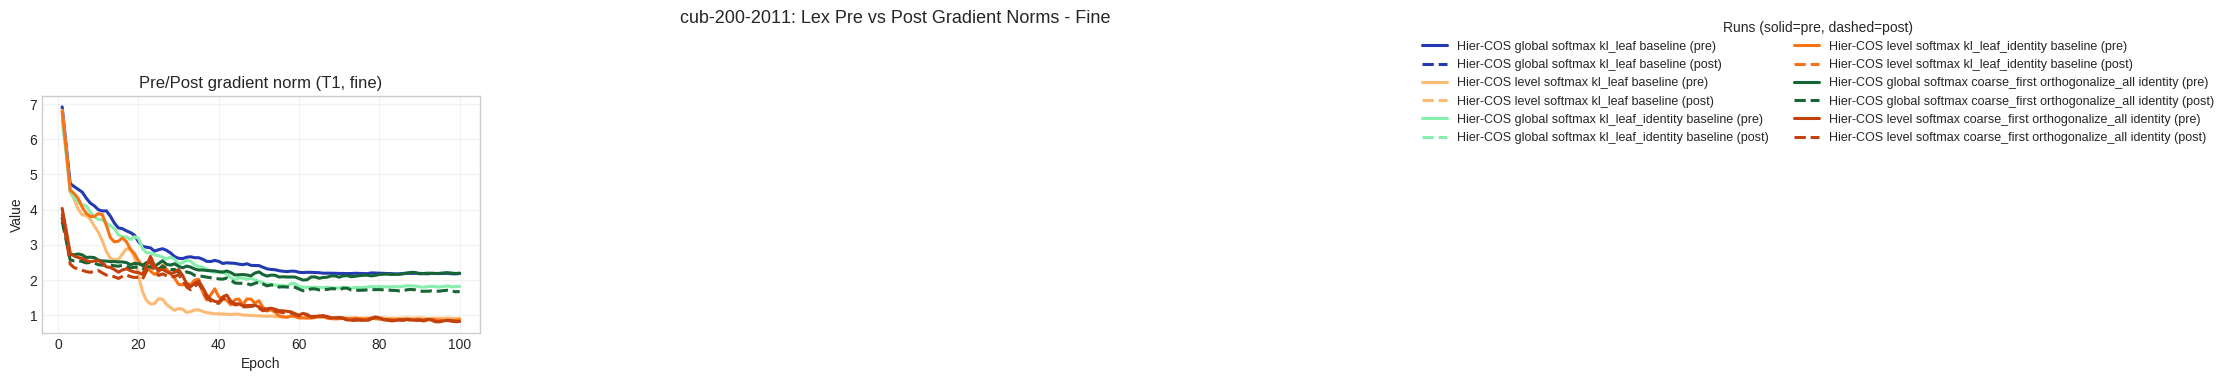

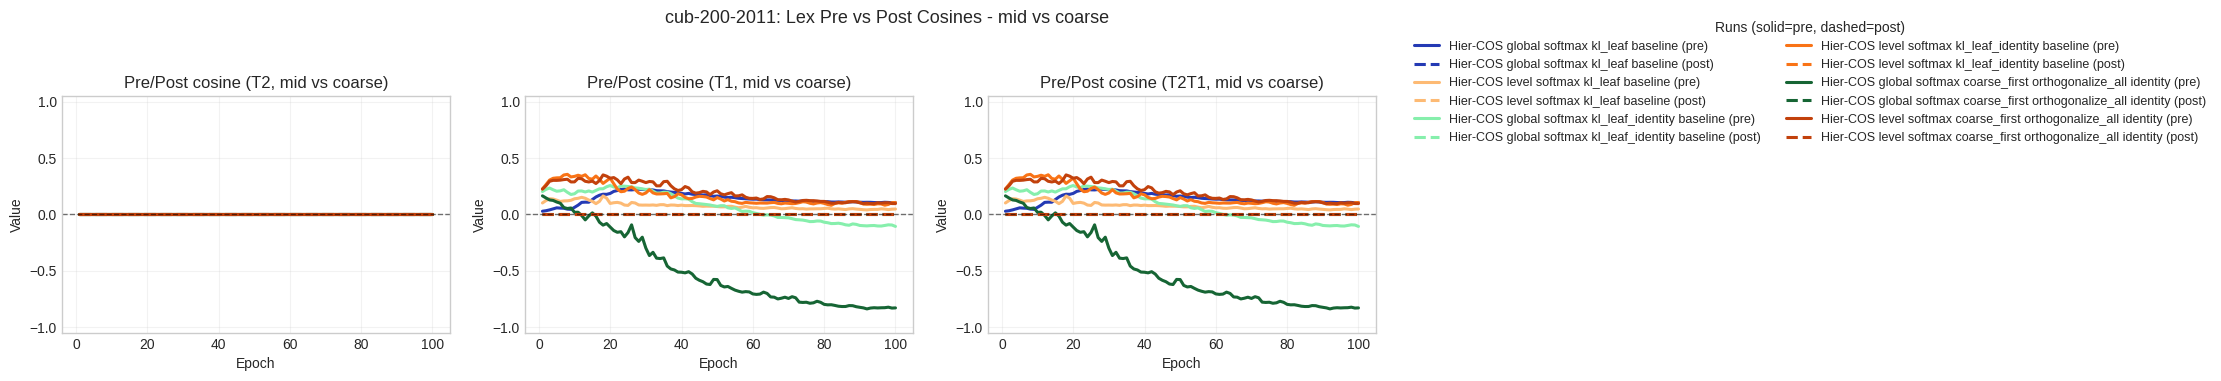

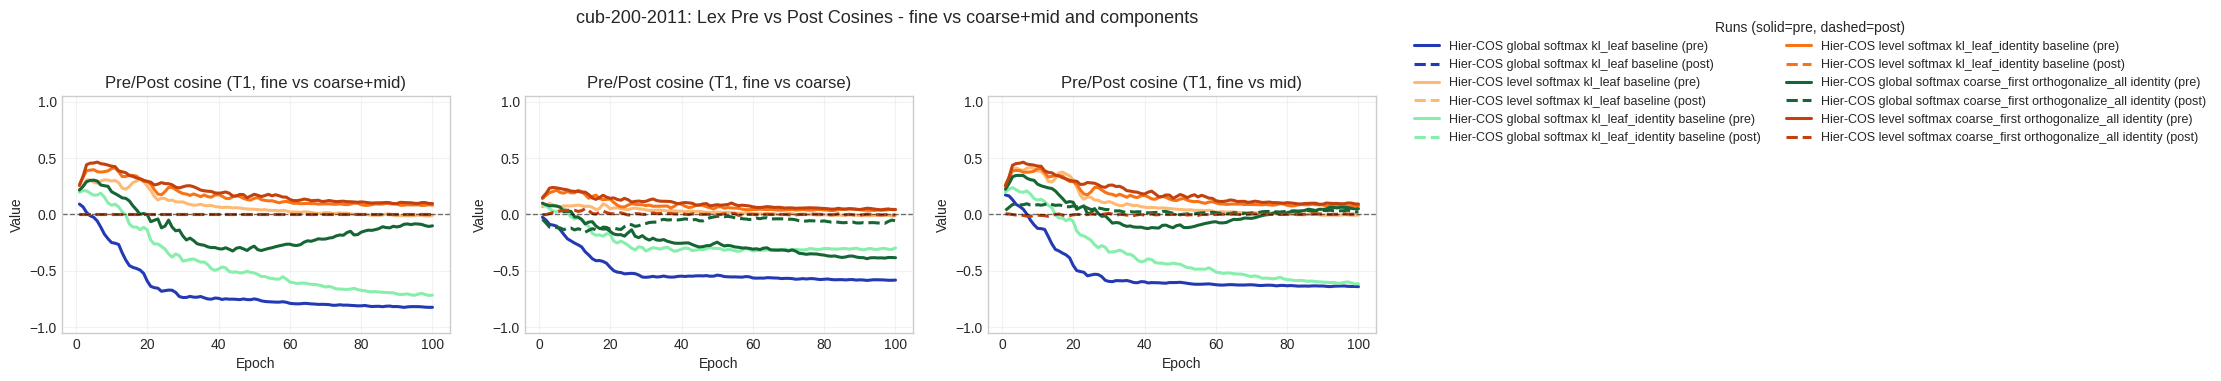

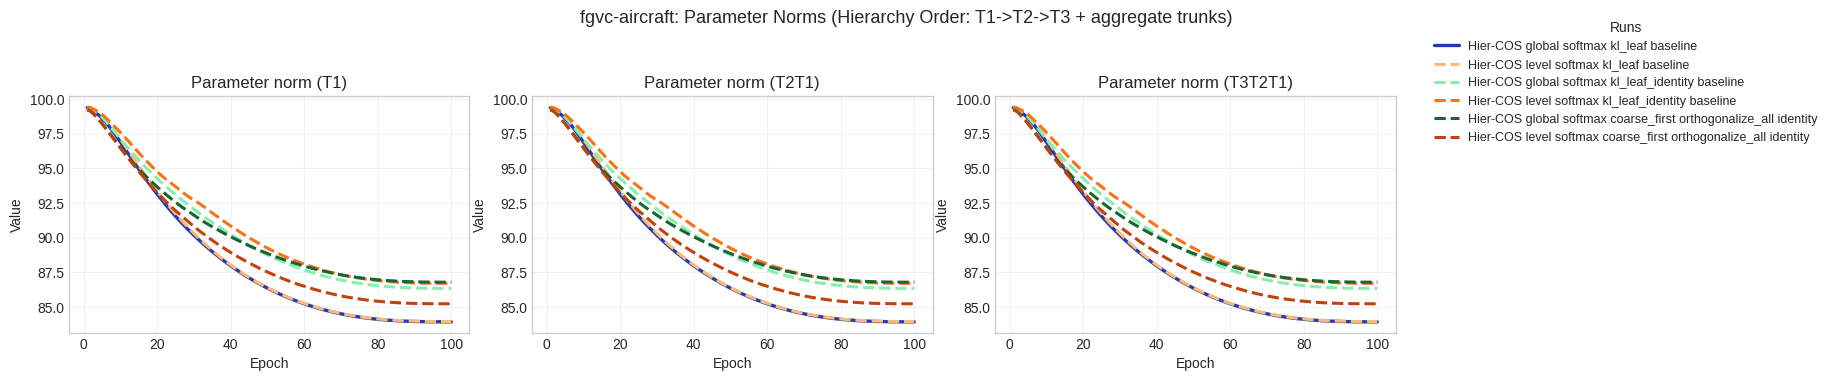

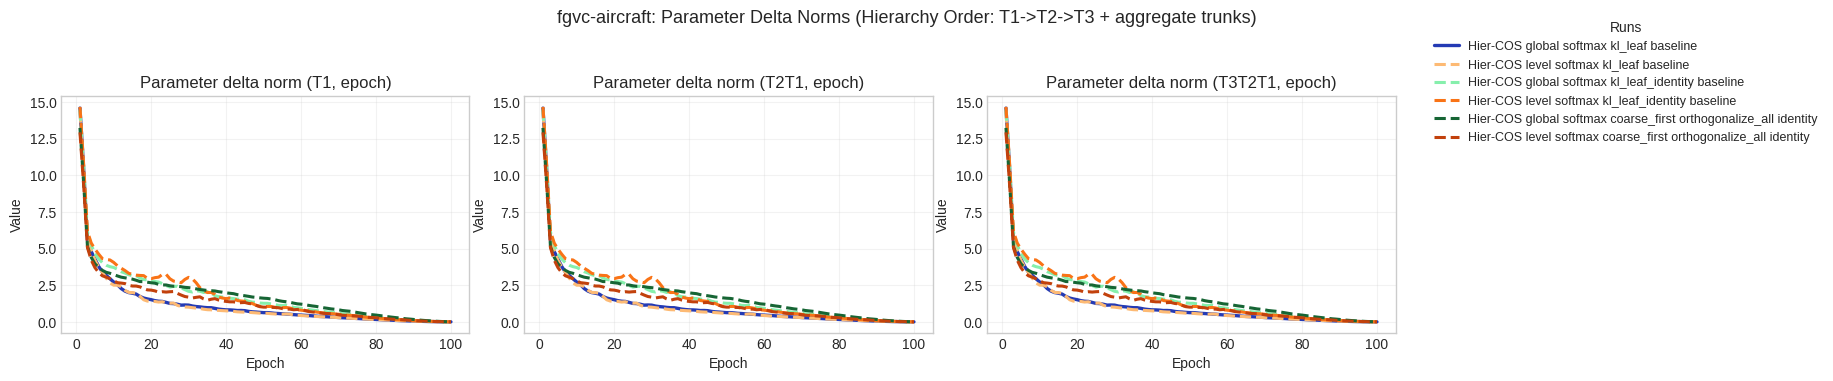

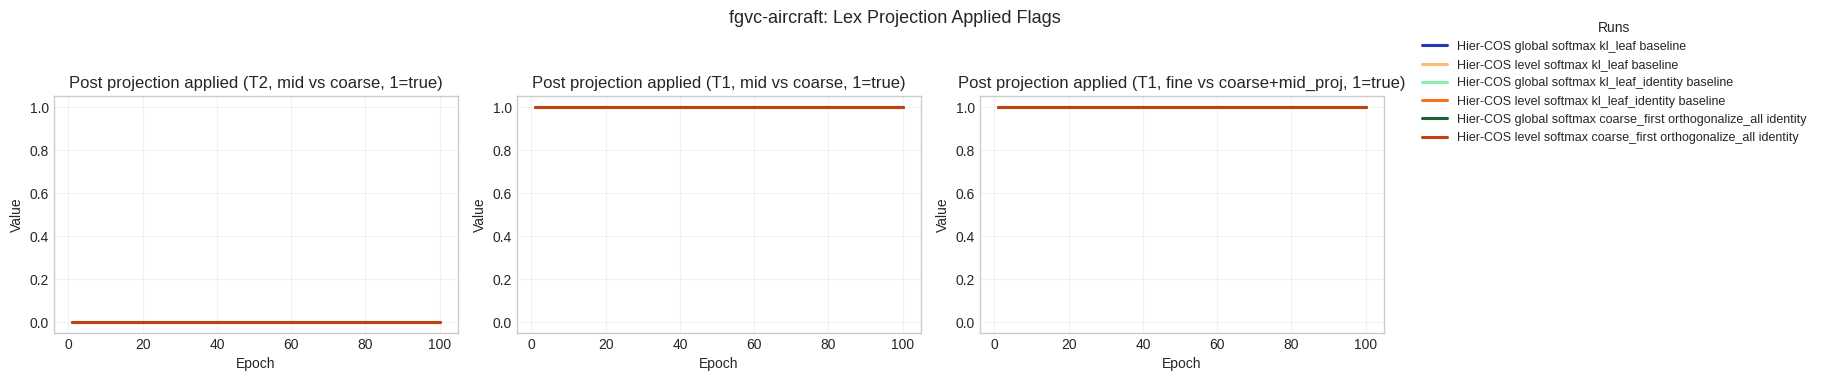

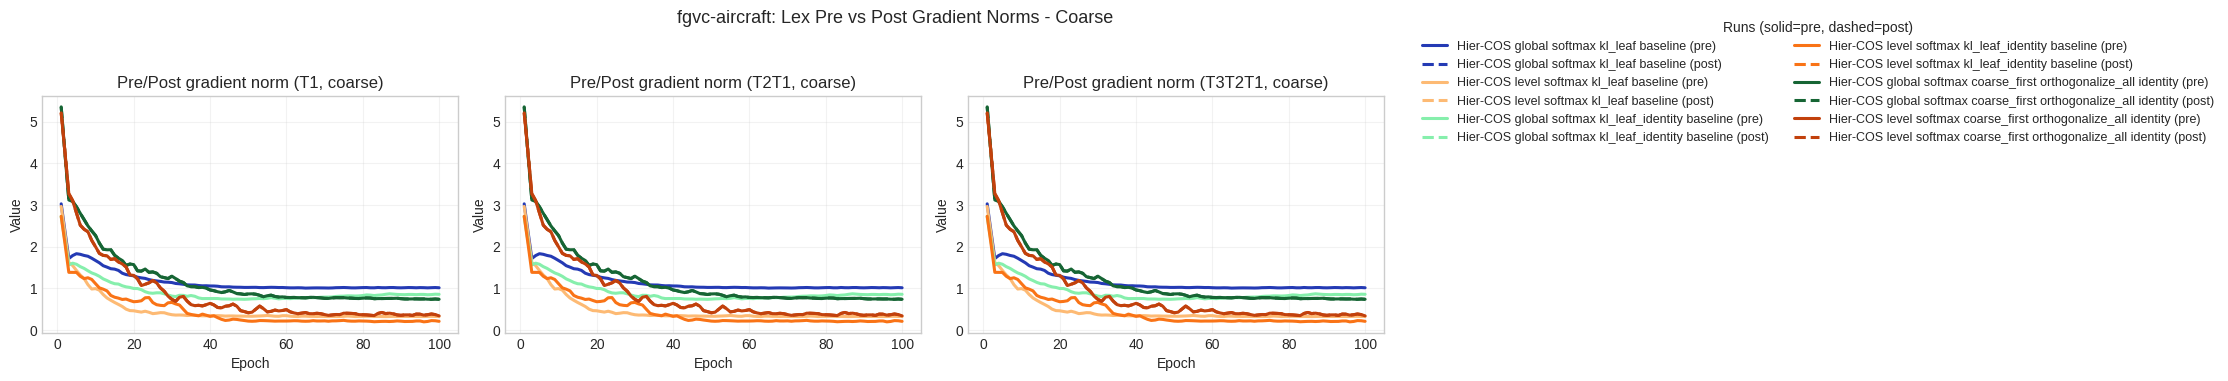

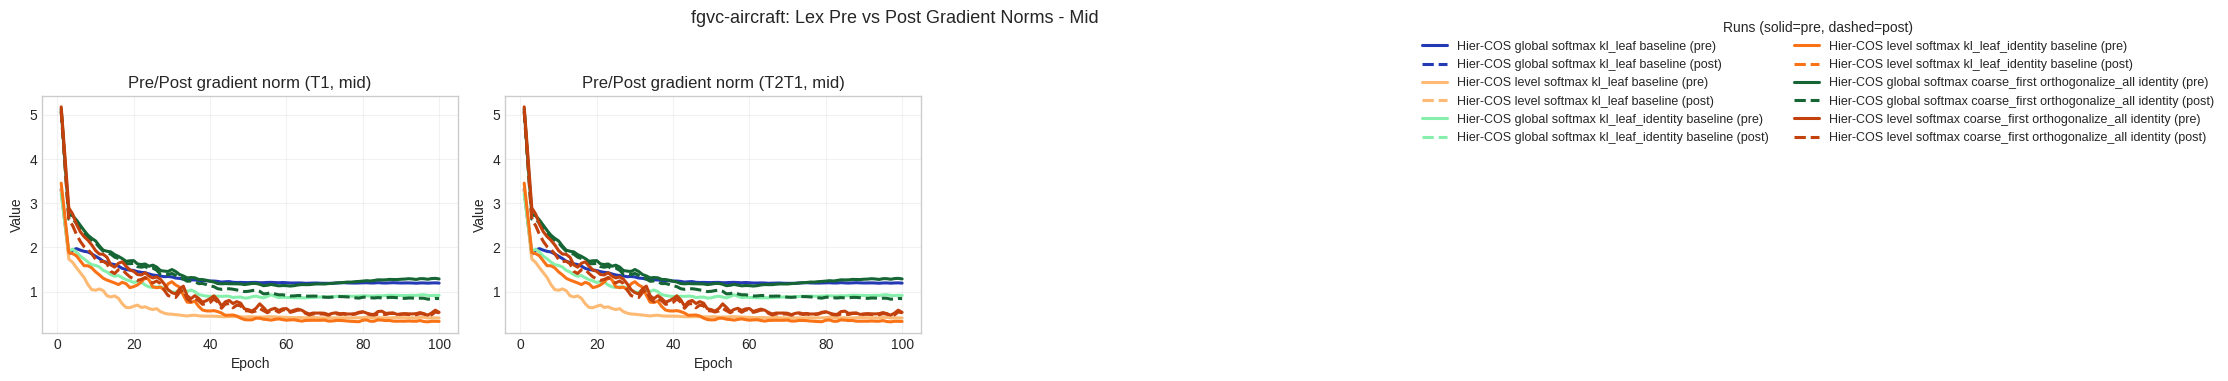

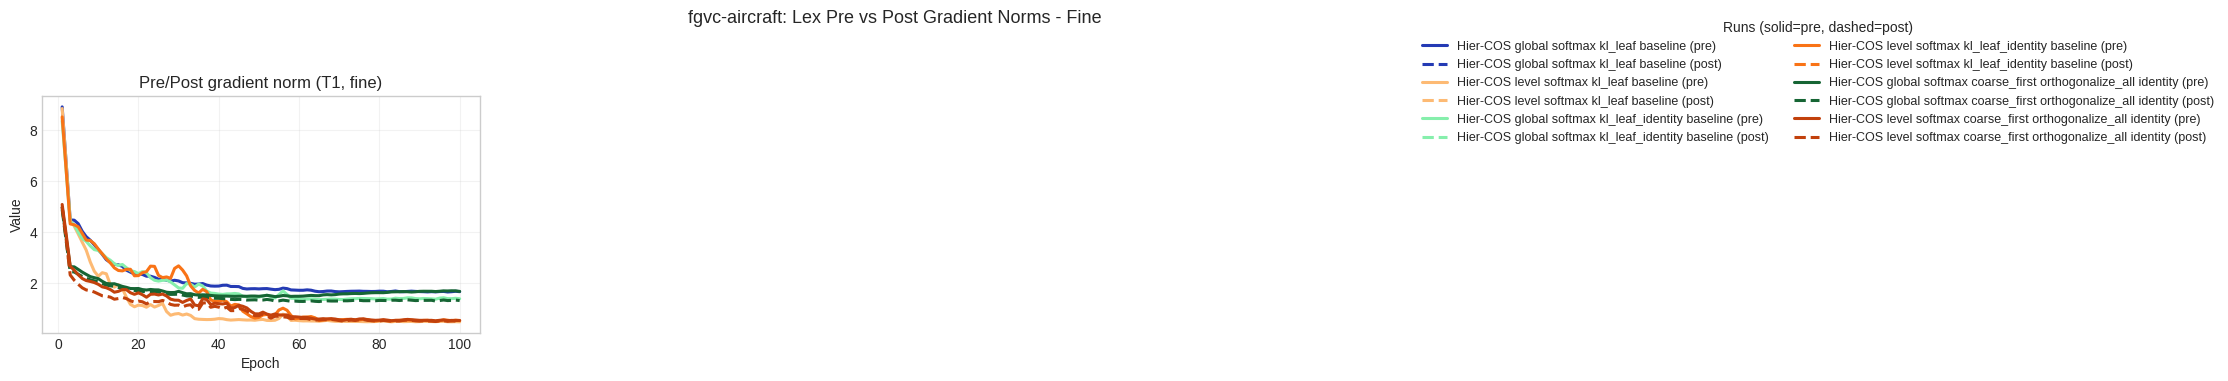

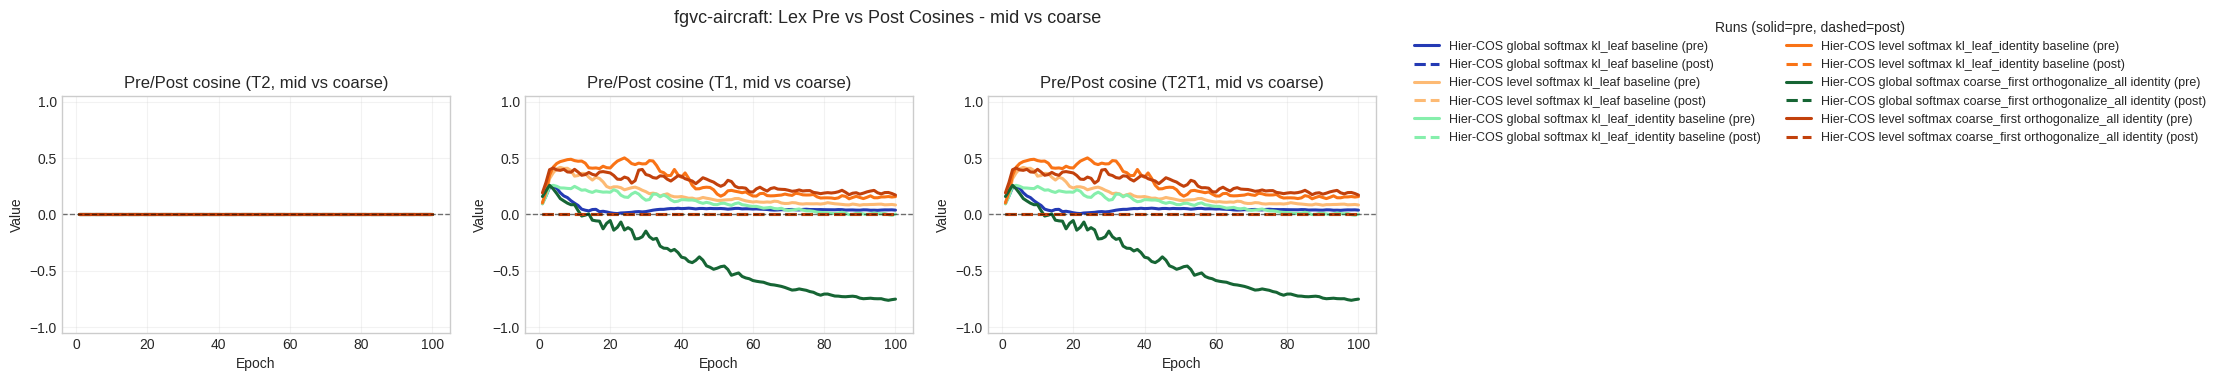

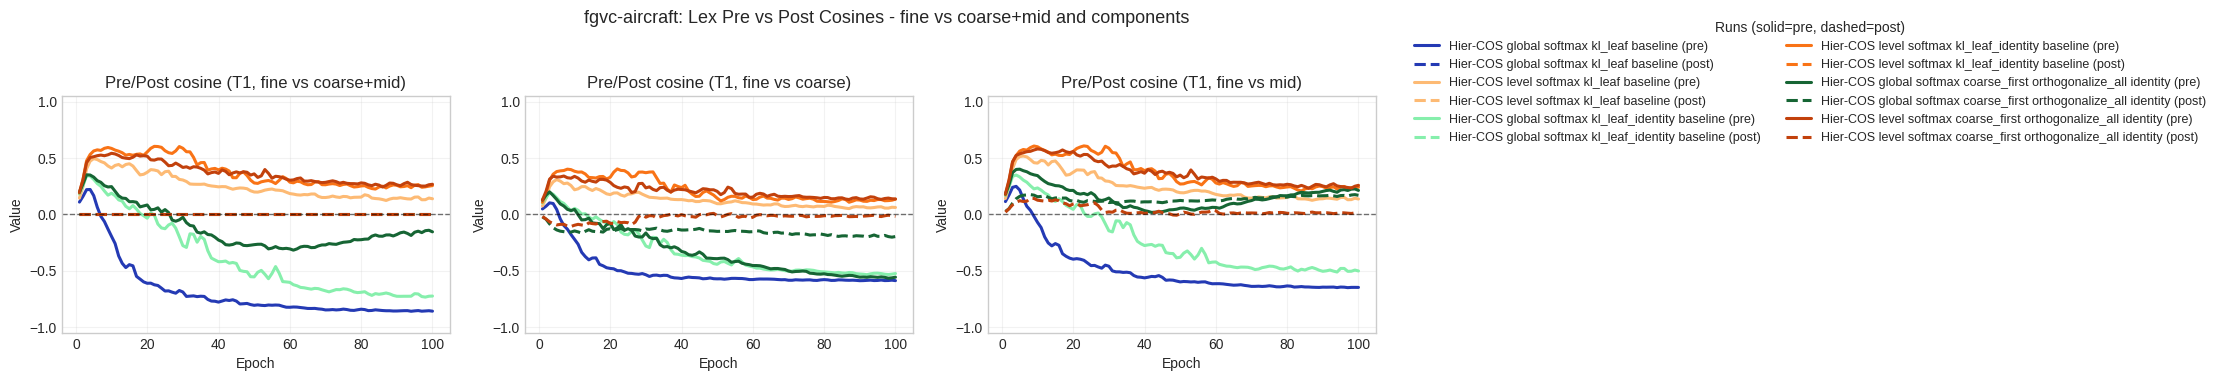

In [18]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)


Interpretation note:

- Large spikes in gradient norms indicate unstable update pressure for that subset/level path.
- If `grad_norm_t1_fine` collapses while `t1` coarse/mid stay high, fine supervision is not effectively reaching shared parameters.
- Negative cosine values indicate level conflict on the corresponding subset.
- `param_norm_*` is scale, `delta_param_norm_*` is per-epoch movement.
- In lex mode, projected cosines should move near 0 (orthogonality on the target mask).
- `post_projection_applied_* = 0` means the corresponding projection step was skipped for numerical safety.


## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:
- color = run
- line style = mode (`topdown` solid, `independent` dashed).

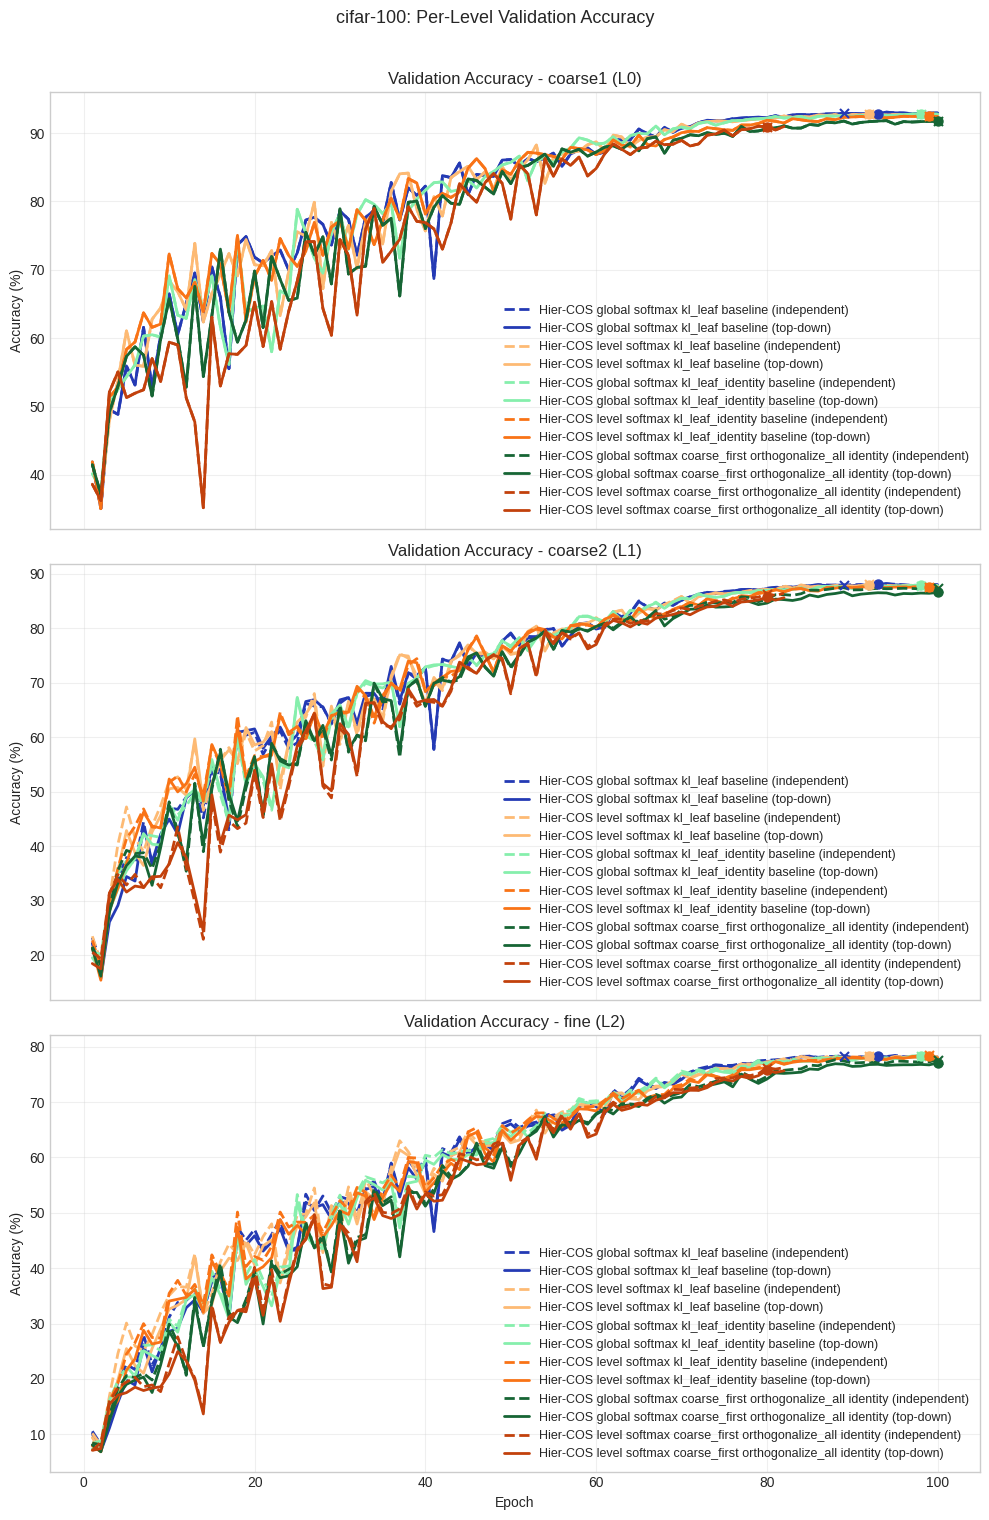

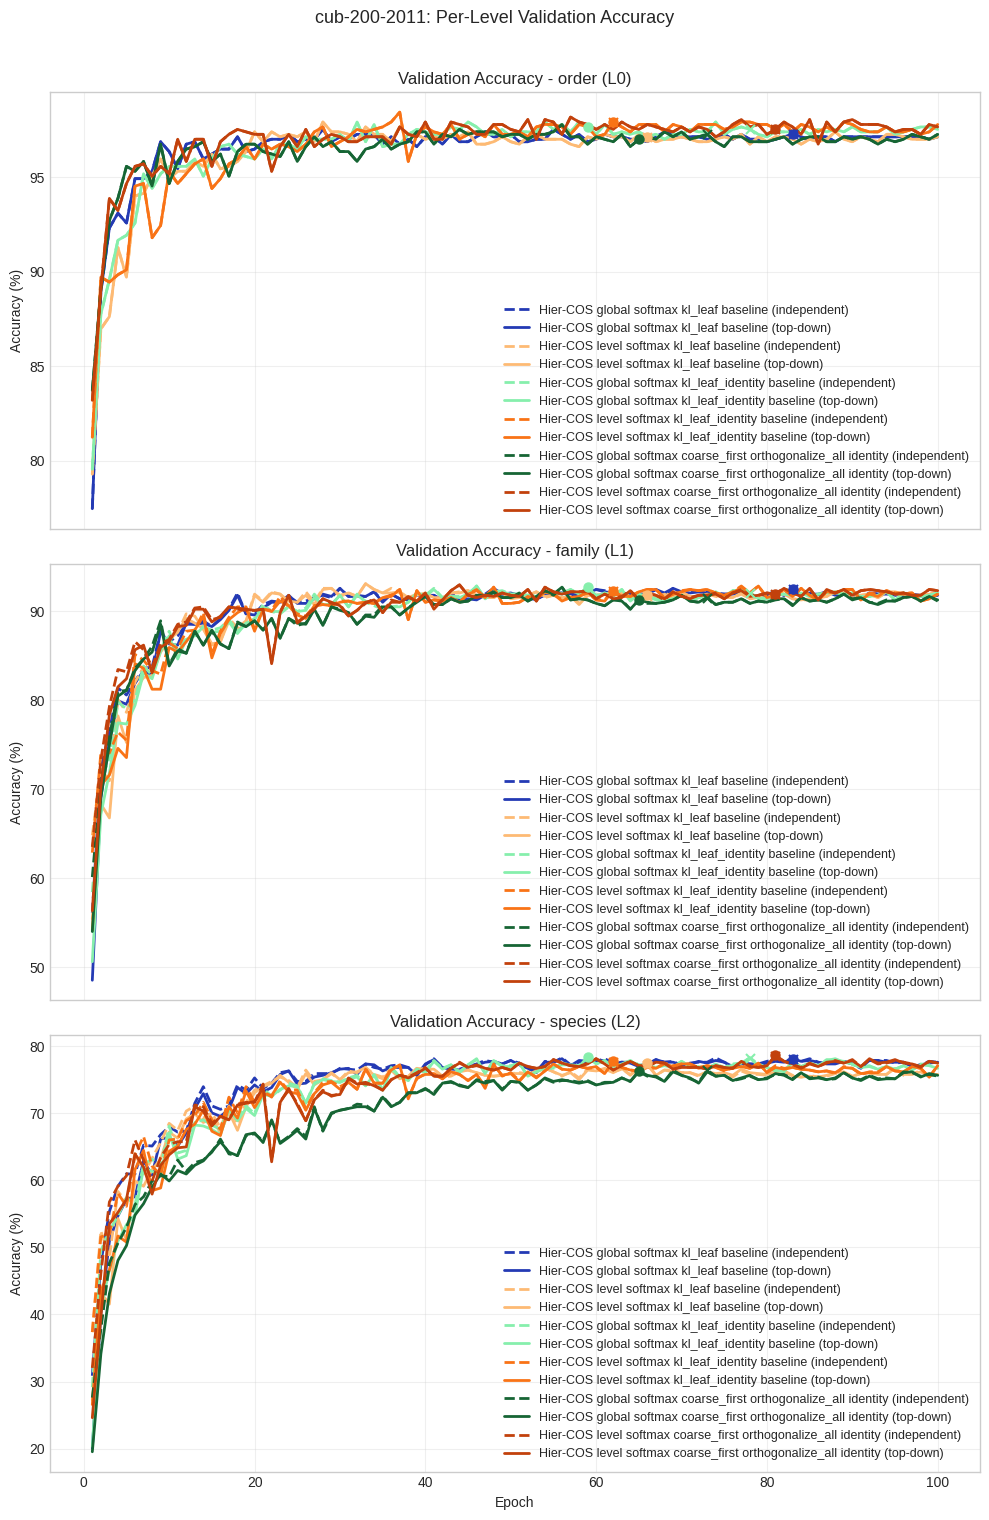

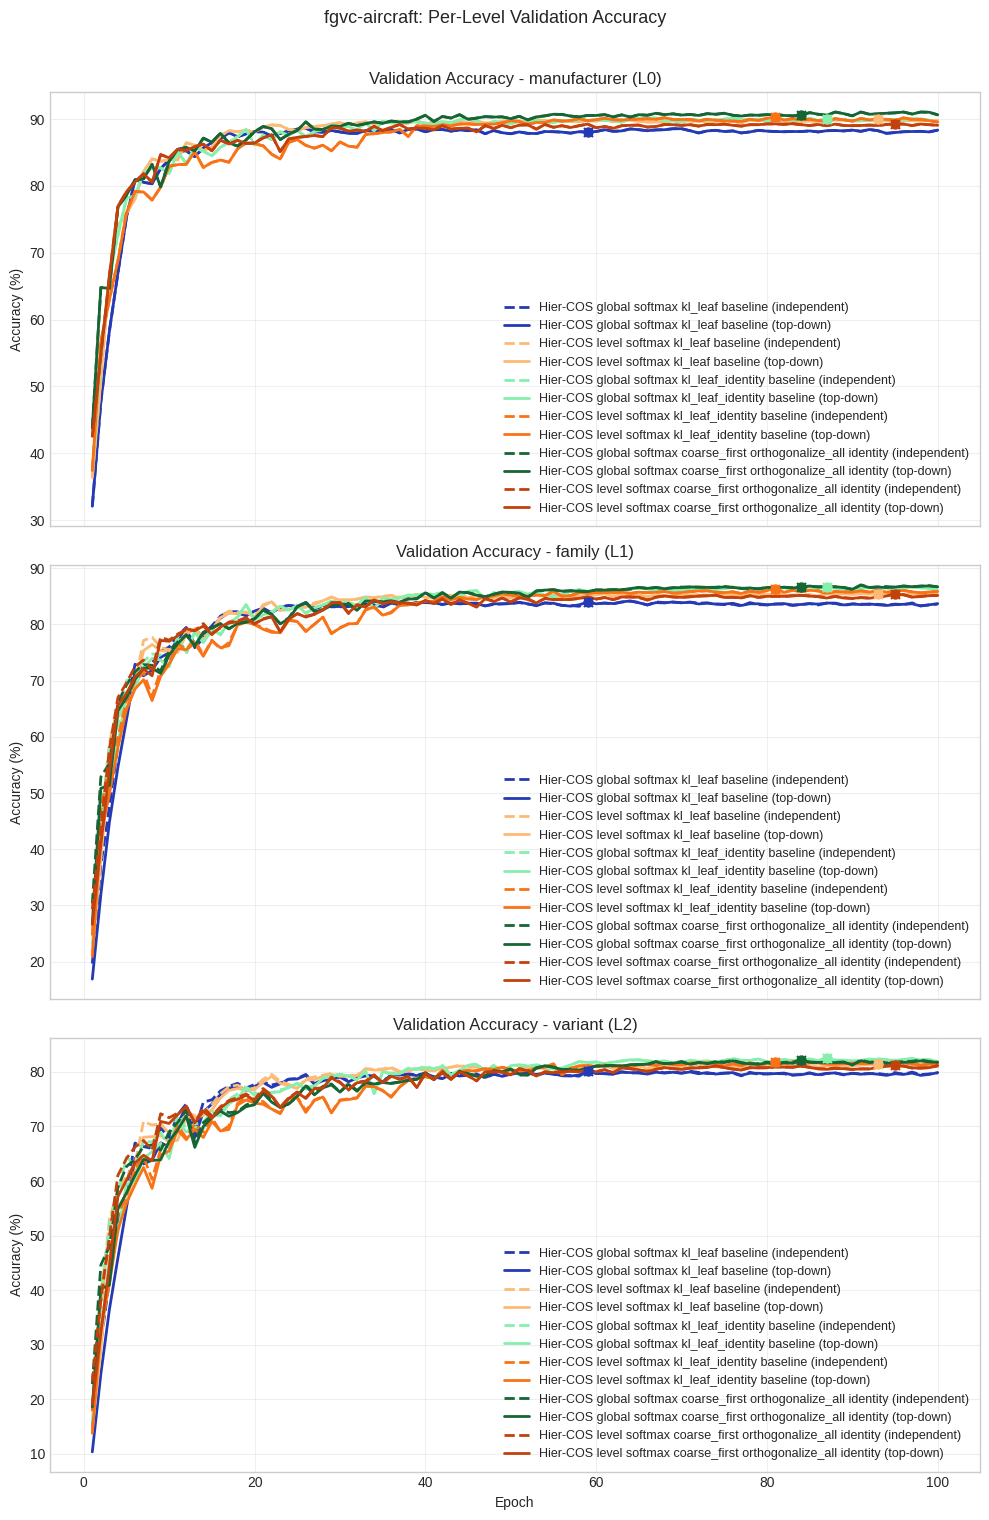

In [19]:
analysis.plot_per_level_validation_accuracy()


Interpretation note:
- In each subplot, solid vs dashed of the same color gives the top-down penalty/gain for that run.
- Across colors, you can compare runs within the same decoding mode by matching line style.
- Larger gaps at deeper levels usually have the strongest impact on final path metrics.

## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected runs and reports deltas versus the first run listed for that dataset (typically the `kl_reg` baseline).


In [20]:
analysis.show_final_test_tables()


### Dataset: `cifar-100`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline (n=1) | Hier-COS level softmax kl_leaf baseline (n=1) | Hier-COS global softmax kl_leaf_identity baseline (n=1) | Hier-COS level softmax kl_leaf_identity baseline (n=1) | Hier-COS global softmax coarse_first orthogonalize_all identity (n=1) | Hier-COS level softmax coarse_first orthogonalize_all identity (n=1) |
|---|---:|---:|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 93/89 | 92/92 | 98/98 | 99/99 | 100/100 | n/a/n/a |
| FPA independent ↑ | **77.60%** | <u>77.26% (-0.34 pp)</u> | 77.10% (-0.50 pp) | 76.58% (-1.02 pp) | 75.80% (-1.80 pp) | n/a |
| FPA top-down ↑ | **78.04%** | <u>77.40% (-0.64 pp)</u> | 77.31% (-0.73 pp) | 76.78% (-1.26 pp) | 75.88% (-2.16 pp) | n/a |
| wAP independent ↑ | **80.07%** | 79.79% (-0.29 pp) | <u>79.87% (-0.20 pp)</u> | 79.21% (-0.86 pp) | 78.92% (-1.15 pp) | n/a |
| wAP top-down ↑ | **80.30%** | <u>79.76% (-0.53 pp)</u> | 79.74% (-0.56 pp) | 79.21% (-1.09 pp) | 78.29% (-2.01 pp) | n/a |
| TICE independent ↓ | 1.09% | **0.80% (-0.29 pp)** | 0.98% (-0.11 pp) | <u>0.91% (-0.18 pp)</u> | 1.24% (+0.15 pp) | n/a |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | n/a |
| AHD independent ↓ | 0.445 | <u>0.443 (-0.001)</u> | **0.441 (-0.004)** | 0.457 (+0.013) | 0.483 (+0.038) | n/a |
| AHD top-down ↓ | **0.433** | 0.441 (+0.008) | <u>0.438 (+0.005)</u> | 0.454 (+0.021) | 0.481 (+0.048) | n/a |
| Acc independent coarse1 (L0) ↑ | 91.28% | <u>91.66% (+0.38 pp)</u> | **91.79% (+0.51 pp)** | 91.26% (-0.02 pp) | 90.51% (-0.76 pp) | n/a |
| Acc top-down coarse1 (L0) ↑ | 91.55% | <u>91.66% (+0.11 pp)</u> | **91.79% (+0.24 pp)** | 91.26% (-0.29 pp) | 90.51% (-1.03 pp) | n/a |
| Acc independent coarse2 (L1) ↑ | 86.79% | <u>86.80% (+0.01 pp)</u> | **87.10% (+0.31 pp)** | 86.53% (-0.26 pp) | 86.37% (-0.42 pp) | n/a |
| Acc top-down coarse2 (L1) ↑ | **87.07%** | 86.81% (-0.26 pp) | <u>87.06% (-0.01 pp)</u> | 86.54% (-0.53 pp) | 85.46% (-1.61 pp) | n/a |
| Acc independent fine (L2) ↑ | **77.83%** | 77.43% (-0.40 pp) | <u>77.47% (-0.36 pp)</u> | 76.78% (-1.05 pp) | 76.50% (-1.33 pp) | n/a |
| Acc top-down fine (L2) ↑ | **78.04%** | <u>77.40% (-0.64 pp)</u> | 77.31% (-0.73 pp) | 76.78% (-1.26 pp) | 75.88% (-2.16 pp) | n/a |

### Dataset: `cub-200-2011`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline (n=1) | Hier-COS level softmax kl_leaf baseline (n=1) | Hier-COS global softmax kl_leaf_identity baseline (n=1) | Hier-COS level softmax kl_leaf_identity baseline (n=1) | Hier-COS global softmax coarse_first orthogonalize_all identity (n=1) | Hier-COS level softmax coarse_first orthogonalize_all identity (n=1) |
|---|---:|---:|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 83/83 | 66/66 | 59/78 | 62/62 | 65/73 | 81/81 |
| FPA independent ↑ | 75.95% | <u>76.42% (+0.47 pp)</u> | 76.06% (+0.10 pp) | **76.61% (+0.66 pp)** | 75.17% (-0.78 pp) | 76.32% (+0.36 pp) |
| FPA top-down ↑ | 76.02% | <u>76.48% (+0.45 pp)</u> | 75.89% (-0.14 pp) | **76.65% (+0.62 pp)** | 74.98% (-1.04 pp) | 76.34% (+0.31 pp) |
| wAP independent ↑ | 79.46% | <u>79.73% (+0.27 pp)</u> | 79.40% (-0.06 pp) | **79.87% (+0.41 pp)** | 78.71% (-0.76 pp) | 79.63% (+0.17 pp) |
| wAP top-down ↑ | 79.26% | <u>79.69% (+0.44 pp)</u> | 79.20% (-0.06 pp) | **79.85% (+0.60 pp)** | 78.52% (-0.73 pp) | 79.63% (+0.38 pp) |
| TICE independent ↓ | 0.59% | 0.43% (-0.16 pp) | 0.14% (-0.45 pp) | 0.21% (-0.38 pp) | **0.03% (-0.56 pp)** | <u>0.12% (-0.47 pp)</u> |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | 0.370 | 0.360 (-0.011) | 0.362 (-0.008) | **0.356 (-0.015)** | 0.366 (-0.004) | <u>0.356 (-0.014)</u> |
| AHD top-down ↓ | 0.369 | 0.359 (-0.010) | 0.366 (-0.003) | **0.355 (-0.014)** | 0.371 (+0.002) | <u>0.356 (-0.013)</u> |
| Acc independent order (L0) ↑ | 96.77% | 96.89% (+0.12 pp) | 97.03% (+0.26 pp) | 96.98% (+0.21 pp) | **97.20% (+0.43 pp)** | <u>97.05% (+0.28 pp)</u> |
| Acc top-down order (L0) ↑ | 96.77% | 96.89% (+0.12 pp) | 96.91% (+0.14 pp) | 96.98% (+0.21 pp) | **97.14% (+0.36 pp)** | <u>97.05% (+0.28 pp)</u> |
| Acc independent family (L1) ↑ | 90.36% | 90.82% (+0.45 pp) | 90.69% (+0.33 pp) | 90.89% (+0.52 pp) | <u>90.97% (+0.61 pp)</u> | **91.01% (+0.64 pp)** |
| Acc top-down family (L1) ↑ | 90.28% | 90.75% (+0.47 pp) | 90.56% (+0.28 pp) | <u>90.85% (+0.57 pp)</u> | 90.80% (+0.52 pp) | **91.02% (+0.75 pp)** |
| Acc independent species (L2) ↑ | 76.27% | <u>76.51% (+0.24 pp)</u> | 76.11% (-0.16 pp) | **76.67% (+0.40 pp)** | 75.17% (-1.09 pp) | 76.34% (+0.07 pp) |
| Acc top-down species (L2) ↑ | 76.02% | <u>76.48% (+0.45 pp)</u> | 75.89% (-0.14 pp) | **76.65% (+0.62 pp)** | 74.98% (-1.04 pp) | 76.34% (+0.31 pp) |

### Dataset: `fgvc-aircraft`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline (n=1) | Hier-COS level softmax kl_leaf baseline (n=1) | Hier-COS global softmax kl_leaf_identity baseline (n=1) | Hier-COS level softmax kl_leaf_identity baseline (n=1) | Hier-COS global softmax coarse_first orthogonalize_all identity (n=1) | Hier-COS level softmax coarse_first orthogonalize_all identity (n=1) |
|---|---:|---:|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 59/59 | 93/93 | 87/87 | 81/81 | 84/84 | 95/95 |
| FPA independent ↑ | 80.20% | 81.01% (+0.81 pp) | **83.44% (+3.25 pp)** | 81.94% (+1.74 pp) | <u>82.39% (+2.19 pp)</u> | 80.32% (+0.12 pp) |
| FPA top-down ↑ | 80.41% | 81.13% (+0.72 pp) | **83.53% (+3.12 pp)** | 81.94% (+1.53 pp) | <u>82.39% (+1.98 pp)</u> | 80.38% (-0.03 pp) |
| wAP independent ↑ | 83.08% | 84.04% (+0.96 pp) | **86.00% (+2.92 pp)** | 84.69% (+1.61 pp) | <u>85.16% (+2.08 pp)</u> | 83.31% (+0.23 pp) |
| wAP top-down ↑ | 83.14% | 84.04% (+0.90 pp) | **86.01% (+2.87 pp)** | 84.63% (+1.49 pp) | <u>85.12% (+1.97 pp)</u> | 83.31% (+0.16 pp) |
| TICE independent ↓ | 1.35% | 0.72% (-0.63 pp) | 0.57% (-0.78 pp) | <u>0.36% (-0.99 pp)</u> | 0.39% (-0.96 pp) | **0.33% (-1.02 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | 0.467 | 0.437 (-0.030) | **0.382 (-0.085)** | 0.419 (-0.048) | <u>0.404 (-0.063)</u> | 0.457 (-0.010) |
| AHD top-down ↓ | 0.462 | 0.435 (-0.026) | **0.380 (-0.081)** | 0.419 (-0.042) | <u>0.404 (-0.058)</u> | 0.455 (-0.006) |
| Acc independent manufacturer (L0) ↑ | 88.82% | 89.51% (+0.69 pp) | **91.02% (+2.19 pp)** | 89.93% (+1.11 pp) | <u>90.53% (+1.71 pp)</u> | 89.09% (+0.27 pp) |
| Acc top-down manufacturer (L0) ↑ | 88.82% | 89.51% (+0.69 pp) | **91.02% (+2.19 pp)** | 89.93% (+1.11 pp) | <u>90.53% (+1.71 pp)</u> | 89.09% (+0.27 pp) |
| Acc independent family (L1) ↑ | 84.44% | 85.85% (+1.41 pp) | **87.32% (+2.88 pp)** | 86.24% (+1.80 pp) | <u>86.72% (+2.28 pp)</u> | 84.98% (+0.54 pp) |
| Acc top-down family (L1) ↑ | 84.62% | 85.85% (+1.23 pp) | **87.41% (+2.79 pp)** | 86.21% (+1.59 pp) | <u>86.69% (+2.07 pp)</u> | 85.01% (+0.39 pp) |
| Acc independent variant (L2) ↑ | 80.41% | 81.13% (+0.72 pp) | **83.56% (+3.16 pp)** | 82.03% (+1.62 pp) | <u>82.45% (+2.04 pp)</u> | 80.41% (+0.00 pp) |
| Acc top-down variant (L2) ↑ | 80.41% | 81.13% (+0.72 pp) | **83.53% (+3.12 pp)** | 81.94% (+1.53 pp) | <u>82.39% (+1.98 pp)</u> | 80.38% (-0.03 pp) |

Interpretation note:
- Metrics are rows and runs are columns.
- Goal arrows are in metric names: `↑` means maximize, `↓` means minimize.
- Non-baseline run cells show `value (delta vs baseline)`.
- Bold cells mark the best run for each metric in the dataset table.
- Delta is computed as `run - baseline`.
